# Task 3: Population-scale variant analysis of the CXCL11 guides, genome-wide off-target coverage (N = 2,504)

This is the *CXCL11* half of `03_variant_analysis_n2504_genome_wide-KM`, isolated so the CRISPRi pool can be reported on its own. The cohort (2,504 individuals), the haplotype reconstruction and both classifiers are identical; only the guide pool is restricted. Every *SERPINB2* guide, figure and table is dropped, so the CRISPRa pool is reported from the two-gene notebook instead.

- **9 eligible CRISPRi guides**, all in the first exon of *CXCL11* on chromosome 4.
- **On-target analysis** reconstructs both haplotypes of all 2,504 individuals at each of the 9 sites.
- **Off-target analysis** evaluates the CRISPOR candidates for those 9 guides on every autosome with a prepared VCF. A *CXCL11* guide's candidates land on many chromosomes, so all 22 autosomal VCFs are still loaded; restricting the gene does not restrict the search.

**Data preparation:** `python utils/prepare_n2504_vcfs.py --chromosomes autosomes` builds VCFs for chr1-22.

**Not evaluated: chrX and chrY.** The 1000 Genomes 20190312 chrX file covers only the pseudoautosomal regions (PAR1 and PAR2), and no chrX candidate lies in either. The release has no chrY file. Candidates on both are reported under *Candidate off-target coverage* and are never counted as unchanged.

Outputs are written to `results/tables/n2504_cxcl11/` and `results/figures/n2504_cxcl11/`, leaving the two-gene results in place.

In [1]:
import os
import sys
from pathlib import Path

# Locate this Task3 folder from wherever the notebook is run, so the paths below
# do not depend on the working directory.
TASK3 = Path.cwd()
while not (TASK3 / 'utils' / 'variant_utils.py').exists() and TASK3 != TASK3.parent:
    TASK3 = TASK3.parent
sys.path.insert(0, str(TASK3))

# GRCh38 and the VCFs are too large for the repository. Set IFN646_DATA to
# wherever you downloaded them; see the README.
REF_DIR = Path(os.environ.get('IFN646_DATA', TASK3.parent / 'data'))

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd
from matplotlib.colors import ListedColormap
from IPython.display import display, Markdown

# Import variant analytics and plotting utilities from utils/
from utils.variant_utils import (
    VariantAnalyzer, orient_sequence, canonical_chromosome,
    plot_gene_grna_architecture, GENE_MODELS,
    plot_offtarget_events_by_chromosome, plot_offtarget_events_by_guide,
    plot_risk_site_ancestry_heatmap, risk_increasing_site_report,
    risk_increasing_guide_by_chromosome
)

# Configure directories - nested under n2504_cxcl11/, so this run does not
# overwrite the two-gene results.
DATA_DIR = REF_DIR
RESULTS_DIR = TASK3 / 'results'
TABLE_DIR = RESULTS_DIR / 'tables' / 'n2504_cxcl11'
FIGURE_DIR = RESULTS_DIR / 'figures' / 'n2504_cxcl11'
VCF_DIR = DATA_DIR / 'vcfs' / 'n2504'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_FASTA = DATA_DIR / 'GRCh38.fa'
METADATA_FILE = TASK3 / 'inputs' / 'n2504' / 'sample_metadata.tsv'

OFFTARGET_XLS = {
    'CXCL11': TASK3 / 'inputs' / 'offtargets_hg38-chr4-76035901-76036222.xls',
}
GENE_REGIONS = {
    'CXCL11': {'chrom': '4', 'start': 76033682, 'end': 76041415, 'mode': 'CRISPRi'},
}

# Initialize VariantAnalyzer with every prepared N=2,504 per-chromosome VCF, so
# off-target candidates on any autosome can be evaluated.
#
# A VCF is loaded only if it actually covers the candidate sites. A VCF with no
# record at a site is read as reference, so loading one that does not cover a
# region would silently report every site there as unchanged.
UNCOVERED_CHROMS = {
    # The 1000 Genomes 20190312 chrX file contains only the pseudoautosomal
    # regions (PAR1 <= 2,781,479 and PAR2 >= 155,701,383). No chrX candidate
    # lies in either, so chrX sites are reported as not evaluated.
    'X': 'source VCF covers only PAR1/PAR2; no chrX candidate lies in a PAR',
}

analyzer = VariantAnalyzer(REFERENCE_FASTA)
for vcf_path in sorted(VCF_DIR.glob('sampled_chr*.norm.vcf.gz')):
    chrom = re.fullmatch(r'sampled_chr(\w+)\.norm\.vcf\.gz', vcf_path.name).group(1)
    if chrom in UNCOVERED_CHROMS:
        print(f'Skipping chr{chrom}: {UNCOVERED_CHROMS[chrom]}')
        continue
    analyzer.add_vcf(chrom, vcf_path)

missing_on_target = [g for g, r in GENE_REGIONS.items() if r['chrom'] not in analyzer.vcfs]
assert not missing_on_target, f'On-target VCF missing for: {missing_on_target}'

def chrom_order(c):
    return (0, int(c)) if str(c).isdigit() else (1, str(c))

# Load N=2,504 sample metadata
sample_metadata = pd.read_csv(METADATA_FILE, sep='\t')
SAMPLES = list(sample_metadata['sample_id'])
sample_meta_dict = sample_metadata.set_index('sample_id').to_dict(orient='index')

print(f"VariantAnalyzer initialized with {len(analyzer.vcfs)} chromosome VCFs: "
      f"{', '.join(sorted(analyzer.vcfs, key=chrom_order))}")

vcf_sample_sets = {c: list(v.header.samples) for c, v in analyzer.vcfs.items()}
reference_samples = vcf_sample_sets[GENE_REGIONS['CXCL11']['chrom']]
mismatched = [c for c, s in vcf_sample_sets.items() if s != reference_samples]
assert not mismatched, f'VCFs with a different sample set or order: {mismatched}'
print(f"Total Cohort Size: {len(SAMPLES)} individuals across 5 continental super-populations.")
display(sample_metadata['super_population_name'].value_counts().reset_index(name='Individual Count'))


VariantAnalyzer initialized with 22 chromosome VCFs: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22
Total Cohort Size: 2504 individuals across 5 continental super-populations.


,super_population_name,Individual Count
0,African,660
1,European,504
2,East Asian,504
3,South Asian,489
4,Admixed American,347


## Data integrity checks

Haplotype-level results are only meaningful on phased genotypes, and every
disruption rate below depends on that. This cell fails the notebook rather
than producing results that cannot be interpreted.


In [2]:

phasing = pd.DataFrame([analyzer.check_phasing(c) for c in analyzer.vcfs])
display(Markdown('**Phasing check — fraction of heterozygous genotypes carrying phase information**'))
display(phasing)
# A chromosome with no heterozygous genotypes in these regions has nothing to
# phase (phased_fraction is 0/0 = NaN), so it cannot fail the check.
has_het = phasing['heterozygous_genotypes'] > 0
if (~has_het).any():
    display(Markdown('No heterozygous genotypes, so phase is irrelevant: '
                     + ', '.join(f'chr{c}' for c in phasing.loc[~has_het, 'chrom'])))
assert (phasing.loc[has_het, 'phased_fraction'] > 0.99).all(), (
    'Haplotype-level analysis requires phased genotypes. See the table above: '
    'one or more VCFs are not phased, so hap1/hap2 assignment is arbitrary.'
)

display(Markdown(
    f'Reconstruction window: `{analyzer.pad}` bp either side of each target, '
    f'bounding the longest deletion that can be detected reaching in from outside.'
))

# Each prepared VCF holds only the regions it was built from, recorded in the
# sibling .n2504_regions_complete marker. Checking the marker against the region
# list the notebook reads later catches the case where one was regenerated and
# the other was not - a mismatch there is silent in every downstream count,
# because a region that was never downloaded looks exactly like a region where
# nobody carries a variant.
REGION_BED = TASK3 / 'inputs' / 'task3_offtarget_regions.bed'
ON_TARGET_REGIONS = {'4': 1, '18': 1}   # added by prepare_n2504_vcfs.py, not in the BED

bed_counts = {}
for line in REGION_BED.read_text().splitlines():
    if line and not line.startswith('#'):
        bed_counts[canonical_chromosome(line.split('\t')[0])] = (
            bed_counts.get(canonical_chromosome(line.split('\t')[0]), 0) + 1)

region_audit = []
for chrom, vcf in analyzer.vcfs.items():
    marker = Path(f'{vcf.filename.decode()}.n2504_regions_complete')
    built = next((int(x.split('=')[1]) for x in marker.read_text().splitlines()
                  if x.startswith('regions=')), None) if marker.exists() else None
    expected = bed_counts.get(str(chrom), 0) + ON_TARGET_REGIONS.get(str(chrom), 0)
    region_audit.append({'chrom': chrom, 'regions_in_vcf': built,
                         'regions_in_bed': expected, 'match': built == expected})

region_audit = pd.DataFrame(region_audit).sort_values('chrom', key=lambda s: s.map(chrom_order))
if not region_audit['match'].all():
    display(Markdown('**VCF / region-list mismatch**'))
    display(region_audit[~region_audit['match']])
    raise RuntimeError(
        'The prepared VCFs were not built from the region list this notebook reads. '
        'Rebuild them with utils/prepare_n2504_vcfs.py before trusting any off-target '
        'result: sites outside the regions a VCF was built from carry no records, and '
        'would be counted as carrying no variant.'
    )
display(Markdown(
    f'Region-list check: all `{len(region_audit)}` VCFs were built from the current '
    f'`{REGION_BED.name}` (`{int(region_audit["regions_in_bed"].sum()):,}` regions).'
))


**Phasing check — fraction of heterozygous genotypes carrying phase information**

,chrom,records_examined,heterozygous_genotypes,phased_heterozygous,phased_fraction
0,1,760,58445,58445,1.0
1,10,472,34286,34286,1.0
2,11,550,44851,44851,1.0
3,12,543,32511,32511,1.0
4,13,315,26871,26871,1.0
5,14,261,18141,18141,1.0
6,15,336,30205,30205,1.0
7,16,319,19048,19048,1.0
8,17,306,28884,28884,1.0
9,18,310,25218,25218,1.0


Reconstruction window: `50` bp either side of each target, bounding the longest deletion that can be detected reaching in from outside.

Region-list check: all `22` VCFs were built from the current `task3_offtarget_regions.bed` (`2,769` regions).

## 1. Load the Eligible CXCL11 gRNAs and Validate Against GRCh38

We load the full pool of eligible guides extracted for Chromosome 4 (*CXCL11*, 9 guides) from the Task 2 audit records. All 9 candidate target sequences (20-nt protospacer + 3-nt PAM = 23-mer) are mapped and validated against the primary reference contig (`NC_000004.12`).

In [3]:
# Ingest the full eligible CXCL11 guide pool
cxcl11_df = pd.read_csv(TASK3 / 'inputs' / 'task2_cxcl11_crispri_full_pool.csv')
cxcl11_df['gene'] = 'CXCL11'
cxcl11_df['mode'] = 'CRISPRi'

guides = cxcl11_df.copy()
guides = guides.rename(columns={
    '#guideId': 'guide_id',
    'mapped_orientation': 'crispor_strand',
    'Composite_Score': 'task2_composite'
})

guides = guides[['gene', 'mode', 'guide_id', 'targetSeq', 'crispor_strand', 'task2_composite']]
guides['targetSeq'] = guides['targetSeq'].astype(str).str.upper().str.replace(r'[^ACGTN]', '', regex=True)

if not guides['targetSeq'].str.len().eq(23).all():
    raise ValueError('Every selected targetSeq must contain exactly 23 bases.')
if guides[['gene', 'guide_id']].duplicated().any():
    raise ValueError('Duplicate gene-guide identifiers were found.')

def map_guide(row):
    region = GENE_REGIONS[row['gene']]
    chrom = region['chrom']
    fasta_chrom = analyzer.fasta_contigs.get(canonical_chromosome(chrom), chrom)
    region_sequence = analyzer.reference.fetch(fasta_chrom, region['start'] - 1, region['end']).upper()
    matches = []
    for strand, query in {'+': row['targetSeq'], '-': orient_sequence(row['targetSeq'], '-')}.items():
        for match in re.finditer(f'(?={re.escape(query)})', region_sequence):
            start = region['start'] + match.start()
            matches.append((start, start + 22, strand))
    if len(matches) != 1:
        return pd.Series({'fasta_chrom': chrom, 'guide_start': pd.NA, 'guide_end': pd.NA, 'genomic_strand': pd.NA, 'mapping_status': 'NOT_FOUND' if not matches else 'AMBIGUOUS'})
    start, end, strand = matches[0]
    genomic = analyzer.reference.fetch(fasta_chrom, start - 1, end).upper()
    oriented = orient_sequence(genomic, strand)
    status = 'VALIDATED' if oriented == row['targetSeq'] and oriented[-3:].endswith('GG') else 'REFERENCE_OR_PAM_MISMATCH'
    return pd.Series({'fasta_chrom': chrom, 'guide_start': start, 'guide_end': end, 'genomic_strand': strand, 'mapping_status': status})

mapping = guides.apply(map_guide, axis=1)
for column in mapping.columns:
    guides[column] = mapping[column].values

if not guides['mapping_status'].eq('VALIDATED').all():
    display(guides.loc[guides['mapping_status'] != 'VALIDATED'])
    raise RuntimeError('At least one selected guide failed reference validation.')

manifest_path = TABLE_DIR / 'task3_n2504_genome_wide_guide_manifest.tsv'
guides.to_csv(manifest_path, sep='\t', index=False)
print(f"Guide manifest saved to: {manifest_path}")
display(guides[['gene', 'guide_id', 'mode', 'targetSeq', 'crispor_strand', 'genomic_strand', 'guide_start', 'guide_end', 'task2_composite', 'mapping_status']])


Guide manifest saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_guide_manifest.tsv


,gene,guide_id,mode,targetSeq,crispor_strand,genomic_strand,guide_start,guide_end,task2_composite,mapping_status
0,CXCL11,76forw,CRISPRi,GAAAGGTGCATGACTCAAAGAGG,reverse,-,76036145,76036167,75.8,VALIDATED
1,CXCL11,264forw,CRISPRi,GAAGGGCATGGCTATAGCCTTGG,reverse,-,76035957,76035979,75.0,VALIDATED
2,CXCL11,261rev,CRISPRi,AGCACACAATATCACAGCCAAGG,forward,+,76035940,76035962,74.2,VALIDATED
3,CXCL11,295forw,CRISPRi,TTGTGTGCTACAGTTGTTCAAGG,reverse,-,76035926,76035948,73.0,VALIDATED
4,CXCL11,77forw,CRISPRi,AAAGGTGCATGACTCAAAGAGGG,reverse,-,76036144,76036166,72.2,VALIDATED
5,CXCL11,106forw,CRISPRi,CTGTGCCATAAAAGGATTGCTGG,reverse,-,76036115,76036137,71.4,VALIDATED
6,CXCL11,145rev,CRISPRi,GTAGAAATGCTGAACATGAAAGG,forward,+,76036056,76036078,67.2,VALIDATED
7,CXCL11,169rev,CRISPRi,GCTTTGCTGCTCTTCTTGGAAGG,forward,+,76036032,76036054,65.8,VALIDATED
8,CXCL11,98forw,CRISPRi,GGAAATTCCTGTGCCATAAAAGG,reverse,-,76036123,76036145,61.2,VALIDATED


## 2. Gene Sequence Architecture Visualisation (All Eligible CXCL11 Guides)

We visualise the full *CXCL11* locus on Chromosome 4, clearly delineating:
- Full gene span and exon-intron structure with directional transcription arrows.
- Highlighted **first exon (exon 1)**, the primary targeting window for transcription regulation.
- The exact genomic positions and cut sites of all 9 candidate gRNAs, with dedicated **PAM motifs (NGG)** colour-coded and labelled to prevent visual overlap.

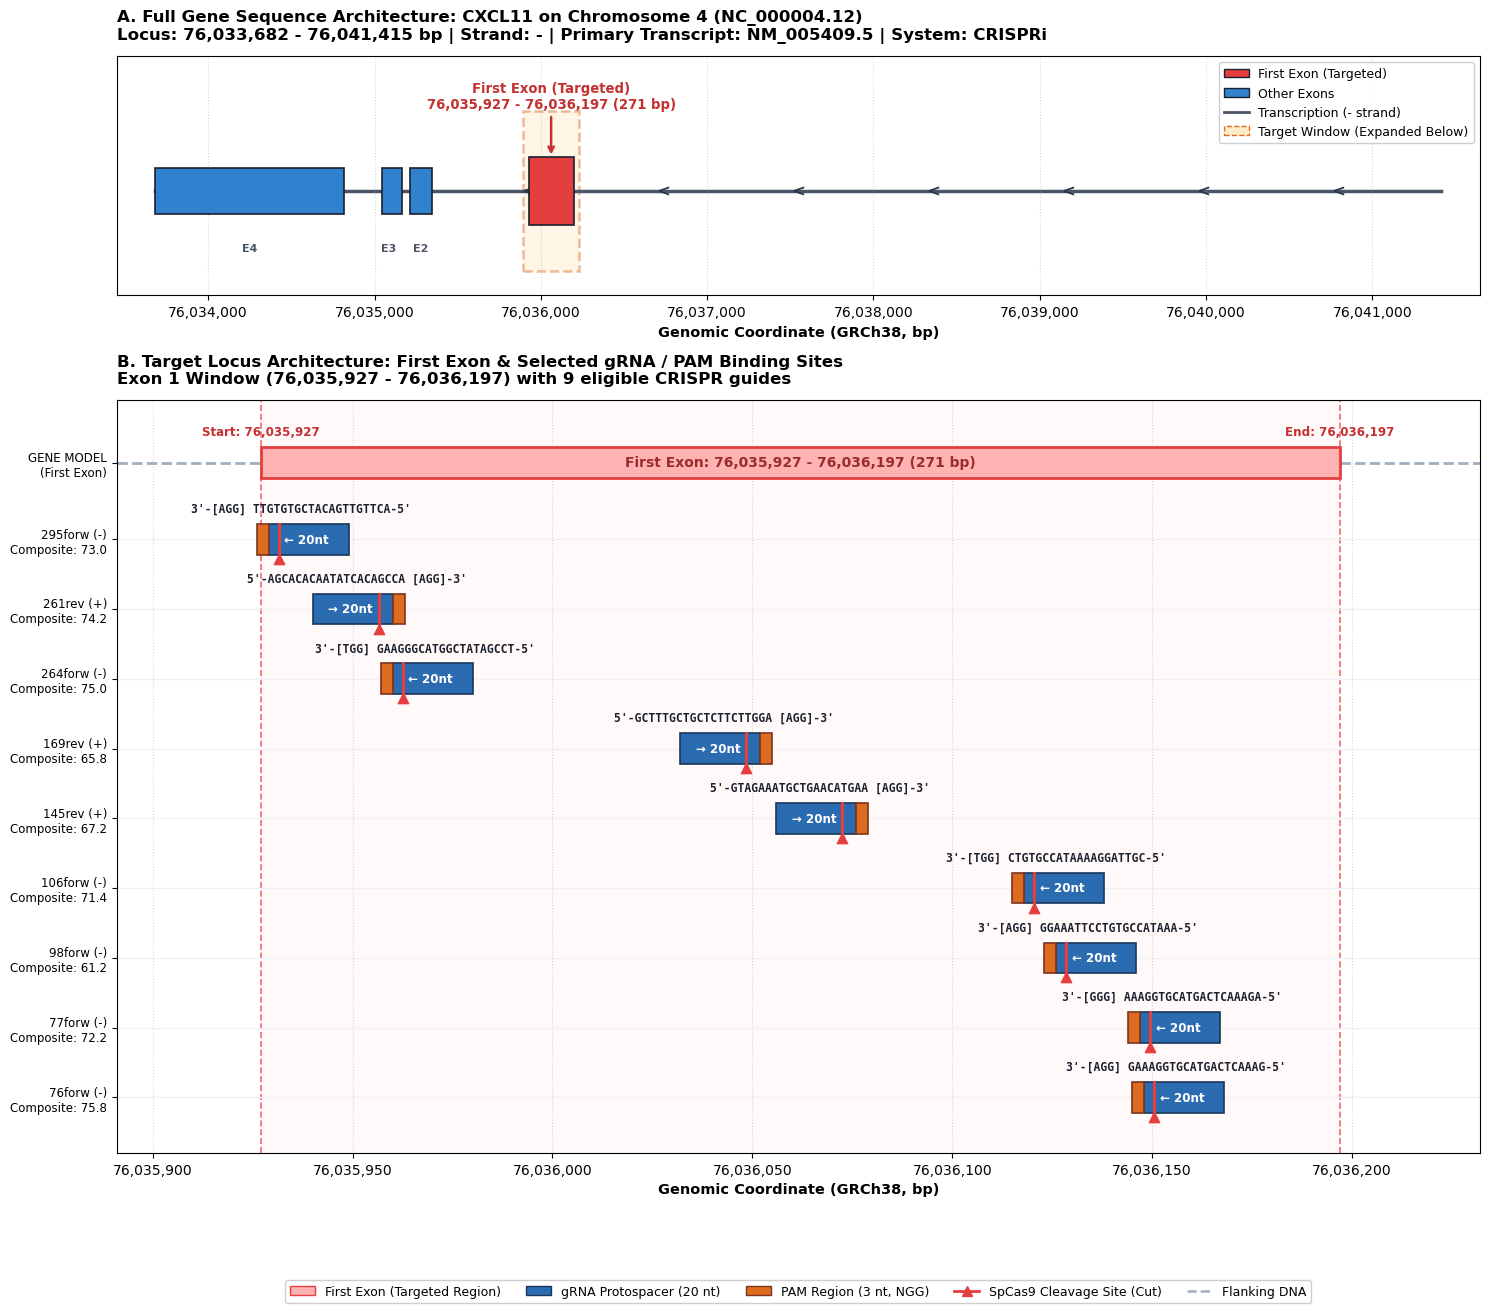

Generated architecture figure for CXCL11


In [4]:
# Generate the publication-quality gene architecture visualisation.
# plot_all_chromosome_targets() always draws both genes, so the single-gene
# plotter is called directly here instead.
architecture_fig = plot_gene_grna_architecture(
    gene_or_chrom='CXCL11',
    guides_df=guides,
    output_path=FIGURE_DIR / 'task3_n2504_genome_wide_cxcl11_grna_architecture.png',
    show=True
)
print("Generated architecture figure for CXCL11")

## 3. On-Target Variant Analysis Across N = 2,504 Individuals (45,072 Haplotypes)

For each of the 2,504 individuals, we reconstruct the personalized sequence of both maternal and paternal haplotypes (Haplotype 1 and Haplotype 2) across all 9 *CXCL11* gRNA target sites (totalling $9 \times 2{,}504 \times 2 = 45{,}072$ reconstructed alleles).

Each reconstructed 23-mer is classified into one of four functional target statuses:
- **`UNCHANGED`**: 100% sequence identity to reference 23-mer; canonical `NGG` PAM intact; fully targetable.
- **`MISMATCHED`**: Canonical `NGG` PAM intact, but 1 or more SNVs present in the 20-nt protospacer (potential cleavage/binding attenuation).
- **`PAM_LOST`**: Single nucleotide variant or indel mutates the essential `NGG` PAM motif, completely abolishing Cas9/dCas9 binding.
- **`INDEL_OR_UNRESOLVED`**: Target site interrupted by an insertion or deletion, so the reconstructed sequence is no longer 23 bases long.

### Individual Targetability States:
- **`PASS` (Biallelic Intact)**: Both alleles are `UNCHANGED` (100% theoretical editing efficacy).
- **`CAUTION` (Heterozygous Disrupted)**: Exactly 1 allele carries a variant/PAM loss; the remaining allele is intact (target knockdown or activation is likely preserved but reduced by ~50%).
- **`FAIL` (Homozygous Escape)**: Both alleles carry disruptive variants/PAM loss; the patient is completely refractory to the therapeutic CRISPR guide.


In [5]:
rows = []
for _, guide in guides.iterrows():
    start, end = int(guide['guide_start']), int(guide['guide_end'])
    chrom = guide['fasta_chrom']
    genomic_strand = guide['genomic_strand']
    target_seq = guide['targetSeq']
    
    for sample_id in SAMPLES:
        a1, a2, rec = analyzer.reconstruct_alleles(chrom, start, end, sample_id)
        for haplotype, allele in enumerate([a1, a2], 1):
            personalised = orient_sequence(allele, genomic_strand)
            status = analyzer.classify_on_target(target_seq, personalised)
            rows.append({
                'sample_id': sample_id,
                'gene': guide['gene'],
                'mode': guide['mode'],
                'guide_id': guide['guide_id'],
                'haplotype': haplotype,
                'reconstruction_status': rec,
                'personalised_23mer': personalised,
                'target_status': status,
                'super_population': sample_meta_dict[sample_id]['super_population'],
                'population': sample_meta_dict[sample_id]['population']
            })

personalised_targets = pd.DataFrame(rows)
targets_tsv = TABLE_DIR / 'task3_n2504_genome_wide_personalised_targets.tsv.gz'
personalised_targets.to_csv(targets_tsv, sep='\t', index=False, compression={'method': 'gzip', 'mtime': 0})
print(f"Personalised targets table saved to: {targets_tsv} ({len(personalised_targets)} alleles)")

# Summarize per sample per guide
guide_sample_summary = (
    personalised_targets.groupby(['sample_id', 'gene', 'mode', 'guide_id', 'super_population'], as_index=False)
    .agg(
        targetable_alleles=('target_status', lambda s: (s == 'UNCHANGED').sum()),
        target_statuses=('target_status', lambda s: ','.join(s)),
        reconstruction_statuses=('reconstruction_status', lambda s: ','.join(s)),
    )
)
guide_sample_summary['individual_status'] = np.select(
    [
        guide_sample_summary['targetable_alleles'] == 2,
        guide_sample_summary['targetable_alleles'] == 1,
    ],
    ['PASS', 'CAUTION'],
    default='FAIL',
)
sample_summary_tsv = TABLE_DIR / 'task3_n2504_genome_wide_guide_sample_summary.tsv.gz'
guide_sample_summary.to_csv(sample_summary_tsv, sep='\t', index=False, compression={'method': 'gzip', 'mtime': 0})
print(f"Guide-sample summary saved to: {sample_summary_tsv}")


Personalised targets table saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_personalised_targets.tsv.gz (45072 alleles)


Guide-sample summary saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_guide_sample_summary.tsv.gz


In [6]:
# Compute cohort-wide biallelic penetrance metrics
penetrance_records = []
N_total = len(SAMPLES)

for (gene, mode, guide_id), grp in guide_sample_summary.groupby(['gene', 'mode', 'guide_id']):
    pass_cnt = (grp['individual_status'] == 'PASS').sum()
    caution_cnt = (grp['individual_status'] == 'CAUTION').sum()
    fail_cnt = (grp['individual_status'] == 'FAIL').sum()
    
    # Haplotype level
    guide_alleles = personalised_targets[
        (personalised_targets['gene'] == gene) & (personalised_targets['guide_id'] == guide_id)
    ]
    unchanged_alleles = (guide_alleles['target_status'] == 'UNCHANGED').sum()
    mismatched_alleles = (guide_alleles['target_status'] == 'MISMATCHED').sum()
    pam_lost_alleles = (guide_alleles['target_status'] == 'PAM_LOST').sum()
    # INDEL means the reconstructed site changed length, so the 23-mer comparison
    # does not apply.
    indel_alleles = (guide_alleles['target_status'] == 'INDEL_OR_UNRESOLVED').sum()
    
    penetrance_records.append({
        'gene': gene,
        'mode': mode,
        'guide_id': guide_id,
        'cohort_size': N_total,
        'biallelic_pass_n': pass_cnt,
        'biallelic_pass_pct': round((pass_cnt / N_total) * 100, 2),
        'heterozygous_caution_n': caution_cnt,
        'heterozygous_caution_pct': round((caution_cnt / N_total) * 100, 2),
        'homozygous_escape_fail_n': fail_cnt,
        'homozygous_escape_fail_pct': round((fail_cnt / N_total) * 100, 2),
        'haplotypes_intact_pct': round((unchanged_alleles / (2 * N_total)) * 100, 2),
        'pam_lost_alleles': pam_lost_alleles,
        'mismatched_alleles': mismatched_alleles,
        'indel_alleles': indel_alleles,
    })

penetrance_df = pd.DataFrame(penetrance_records).sort_values(
    ['gene', 'biallelic_pass_pct'], ascending=[True, False]
)
penetrance_tsv = TABLE_DIR / 'task3_n2504_genome_wide_biallelic_penetrance.tsv'
penetrance_df.to_csv(penetrance_tsv, sep='\t', index=False)
print(f"Biallelic penetrance summary saved to: {penetrance_tsv}")
display(penetrance_df)


Biallelic penetrance summary saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_biallelic_penetrance.tsv


,gene,mode,guide_id,cohort_size,biallelic_pass_n,biallelic_pass_pct,heterozygous_caution_n,heterozygous_caution_pct,homozygous_escape_fail_n,homozygous_escape_fail_pct,haplotypes_intact_pct,pam_lost_alleles,mismatched_alleles,indel_alleles
0,CXCL11,CRISPRi,106forw,2504,2504,100.00,0,0.00,0,0.0,100.00,0,0,0
1,CXCL11,CRISPRi,145rev,2504,2504,100.00,0,0.00,0,0.0,100.00,0,0,0
2,CXCL11,CRISPRi,169rev,2504,2504,100.00,0,0.00,0,0.0,100.00,0,0,0
5,CXCL11,CRISPRi,295forw,2504,2504,100.00,0,0.00,0,0.0,100.00,0,0,0
3,CXCL11,CRISPRi,261rev,2504,2503,99.96,1,0.04,0,0.0,99.98,1,0,0
4,CXCL11,CRISPRi,264forw,2504,2503,99.96,1,0.04,0,0.0,99.98,0,1,0
8,CXCL11,CRISPRi,98forw,2504,2502,99.92,2,0.08,0,0.0,99.96,0,2,0
6,CXCL11,CRISPRi,76forw,2504,2501,99.88,3,0.12,0,0.0,99.94,0,2,1
7,CXCL11,CRISPRi,77forw,2504,2501,99.88,3,0.12,0,0.0,99.94,0,2,1


In [7]:
# Compute ancestry-stratified disruption rates across 5 super-populations
ancestry_records = []
super_pops = ['EUR', 'AFR', 'EAS', 'SAS', 'AMR']

for (gene, mode, guide_id), grp in guide_sample_summary.groupby(['gene', 'mode', 'guide_id']):
    row = {'gene': gene, 'mode': mode, 'guide_id': guide_id}
    for sp in super_pops:
        sp_grp = grp[grp['super_population'] == sp]
        sp_total = len(sp_grp)
        sp_pass = (sp_grp['individual_status'] == 'PASS').sum()
        sp_disrupted = sp_grp['individual_status'].isin(['CAUTION', 'FAIL']).sum()
        disrupt_pct = round((sp_disrupted / sp_total) * 100, 2) if sp_total > 0 else 0.0
        row[f'{sp}_total'] = sp_total
        row[f'{sp}_disrupted_n'] = sp_disrupted
        row[f'{sp}_disruption_pct'] = disrupt_pct
    ancestry_records.append(row)

ancestry_df = pd.DataFrame(ancestry_records)
ancestry_tsv = TABLE_DIR / 'task3_n2504_genome_wide_ancestry_stratification.tsv'
ancestry_df.to_csv(ancestry_tsv, sep='\t', index=False)
print(f"Ancestry stratification summary saved to: {ancestry_tsv}")
# Show counts alongside percentages: a sub-1% rate in a 504-person group is
# one or two individuals, which a percentage alone conceals.
display(ancestry_df[['gene', 'guide_id'] + [
    f'{sp}_{suffix}' for sp in super_pops for suffix in ('disrupted_n', 'disruption_pct')
]])


Ancestry stratification summary saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_ancestry_stratification.tsv


,gene,guide_id,EUR_disrupted_n,EUR_disruption_pct,AFR_disrupted_n,AFR_disruption_pct,EAS_disrupted_n,EAS_disruption_pct,SAS_disrupted_n,SAS_disruption_pct,AMR_disrupted_n,AMR_disruption_pct
0,CXCL11,106forw,0,0.0,0,0.0,0,0.0,0,0.0,0,0.00
1,CXCL11,145rev,0,0.0,0,0.0,0,0.0,0,0.0,0,0.00
2,CXCL11,169rev,0,0.0,0,0.0,0,0.0,0,0.0,0,0.00
3,CXCL11,261rev,0,0.0,0,0.0,1,0.2,0,0.0,0,0.00
4,CXCL11,264forw,0,0.0,0,0.0,1,0.2,0,0.0,0,0.00
5,CXCL11,295forw,0,0.0,0,0.0,0,0.0,0,0.0,0,0.00
6,CXCL11,76forw,0,0.0,0,0.0,2,0.4,0,0.0,1,0.29
7,CXCL11,77forw,0,0.0,0,0.0,2,0.4,0,0.0,1,0.29
8,CXCL11,98forw,0,0.0,2,0.3,0,0.0,0,0.0,0,0.00


## 4. Visualisation of Population Penetrance and Ancestry Stratification

We generate three key figures that highlight how human genetic variation influences guide suitability across populations:
1. **Ancestry Disruption Heatmap**: Disruption percentage across continental ancestries (EUR, AFR, EAS, SAS, AMR) for all 9 candidate *CXCL11* guides.
2. **Biallelic Penetrance Waterfall**: Stacked bar chart showing the proportion of patients with full targeting capability (`PASS`), partial editing (`CAUTION`), or complete therapeutic escape (`FAIL`).
3. **Cohort Comparison ($N=7$ vs $N=2,504$)**: Direct juxtaposition showing how evaluating only 7 individuals gave a false impression of 100% universal targetability, whereas $N=2{,}504$ uncovers significant ancestral failure modes.


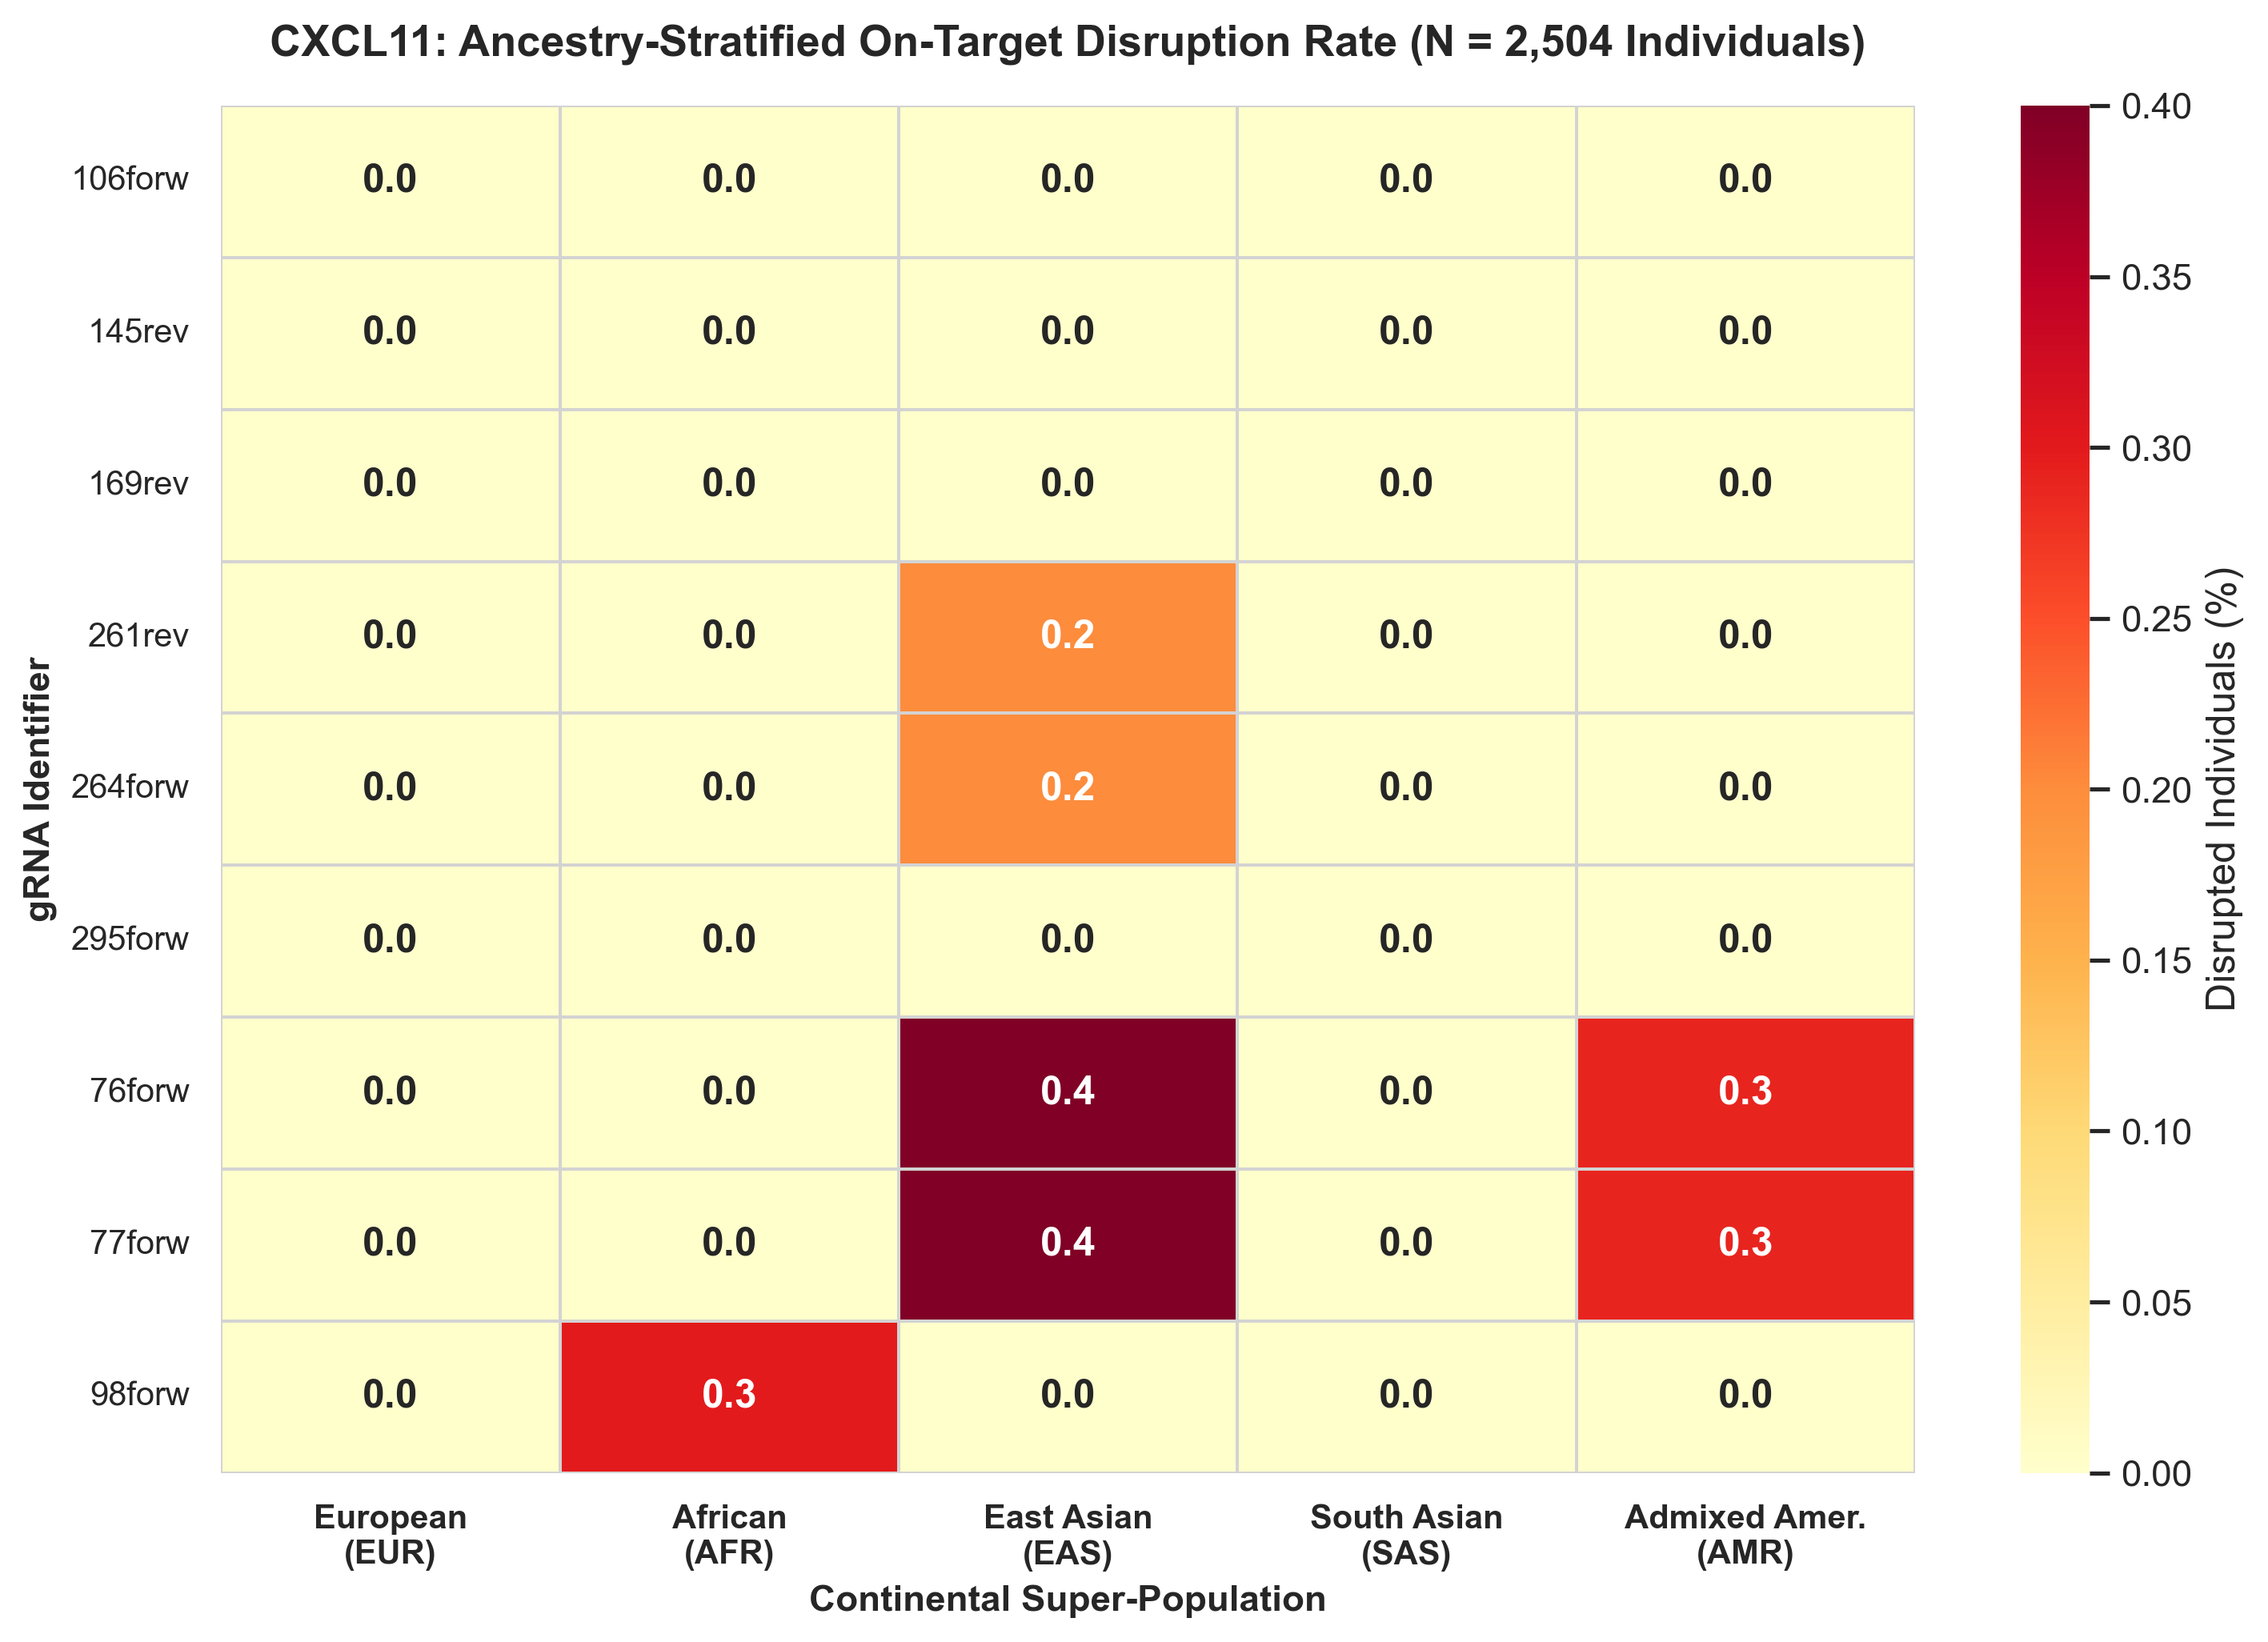

Saved: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/figures/n2504_cxcl11/task3_n2504_genome_wide_ancestry_disruption_heatmap.png


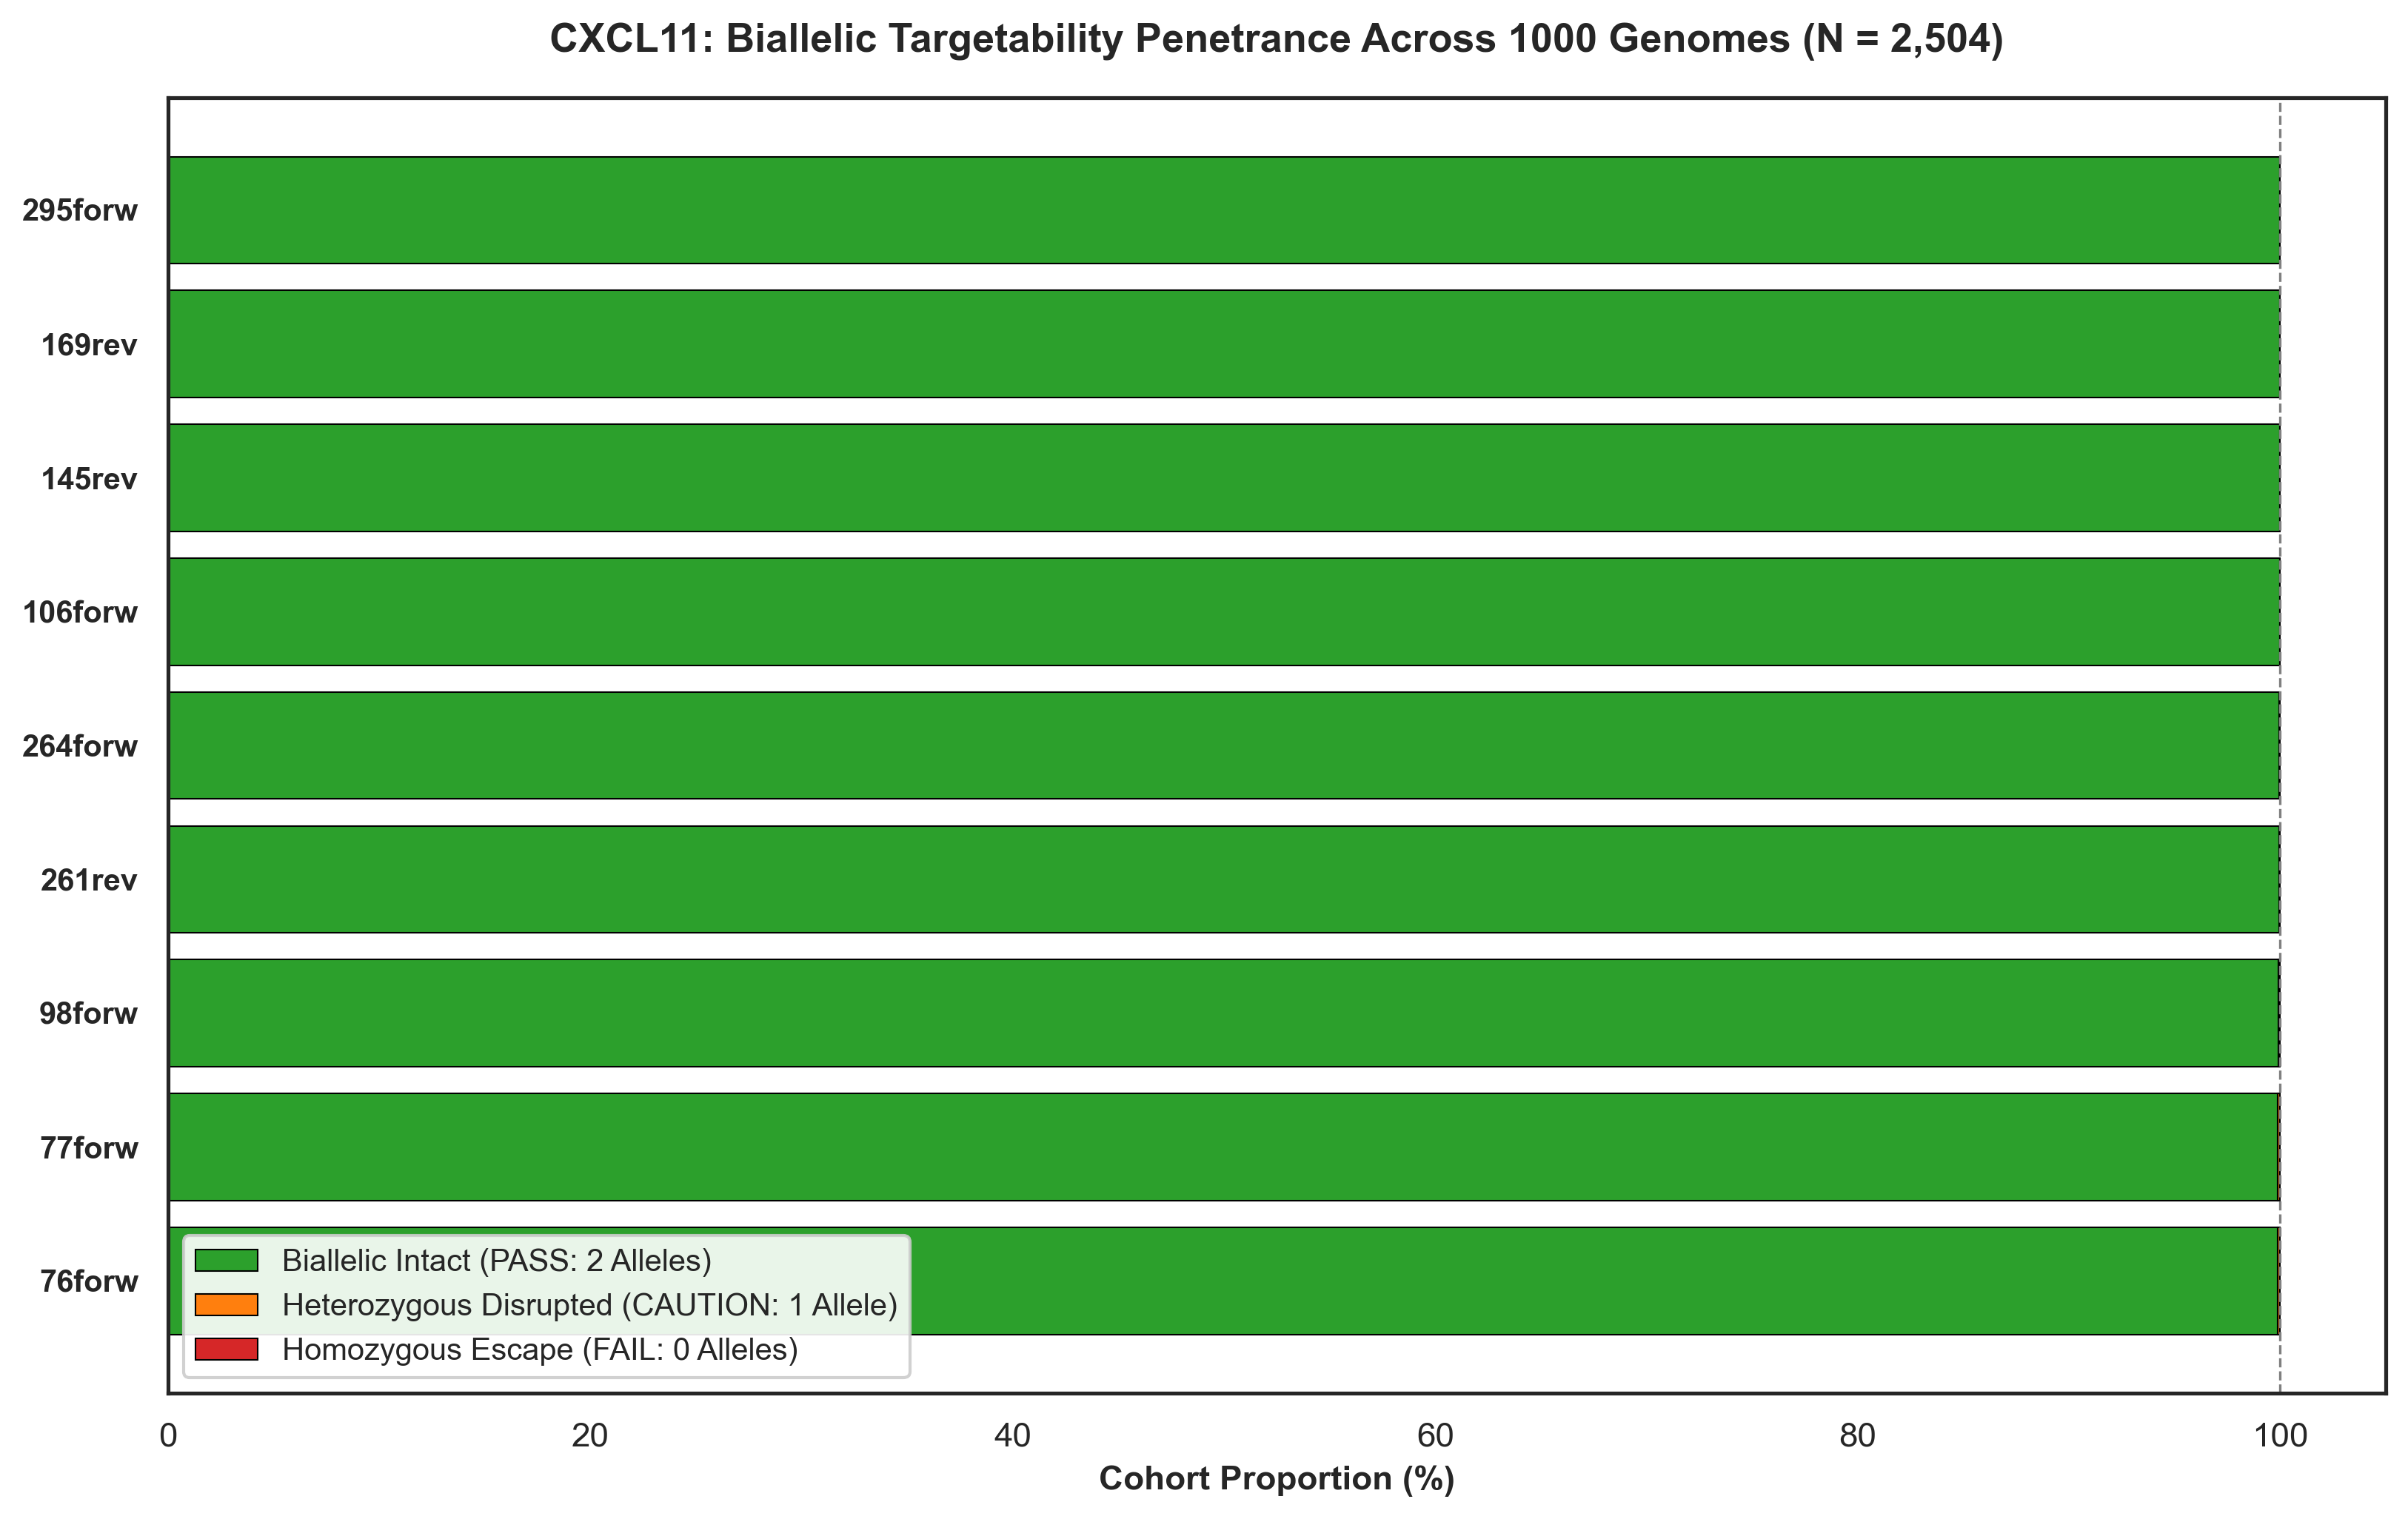

Saved: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/figures/n2504_cxcl11/task3_n2504_genome_wide_biallelic_penetrance_waterfall.png


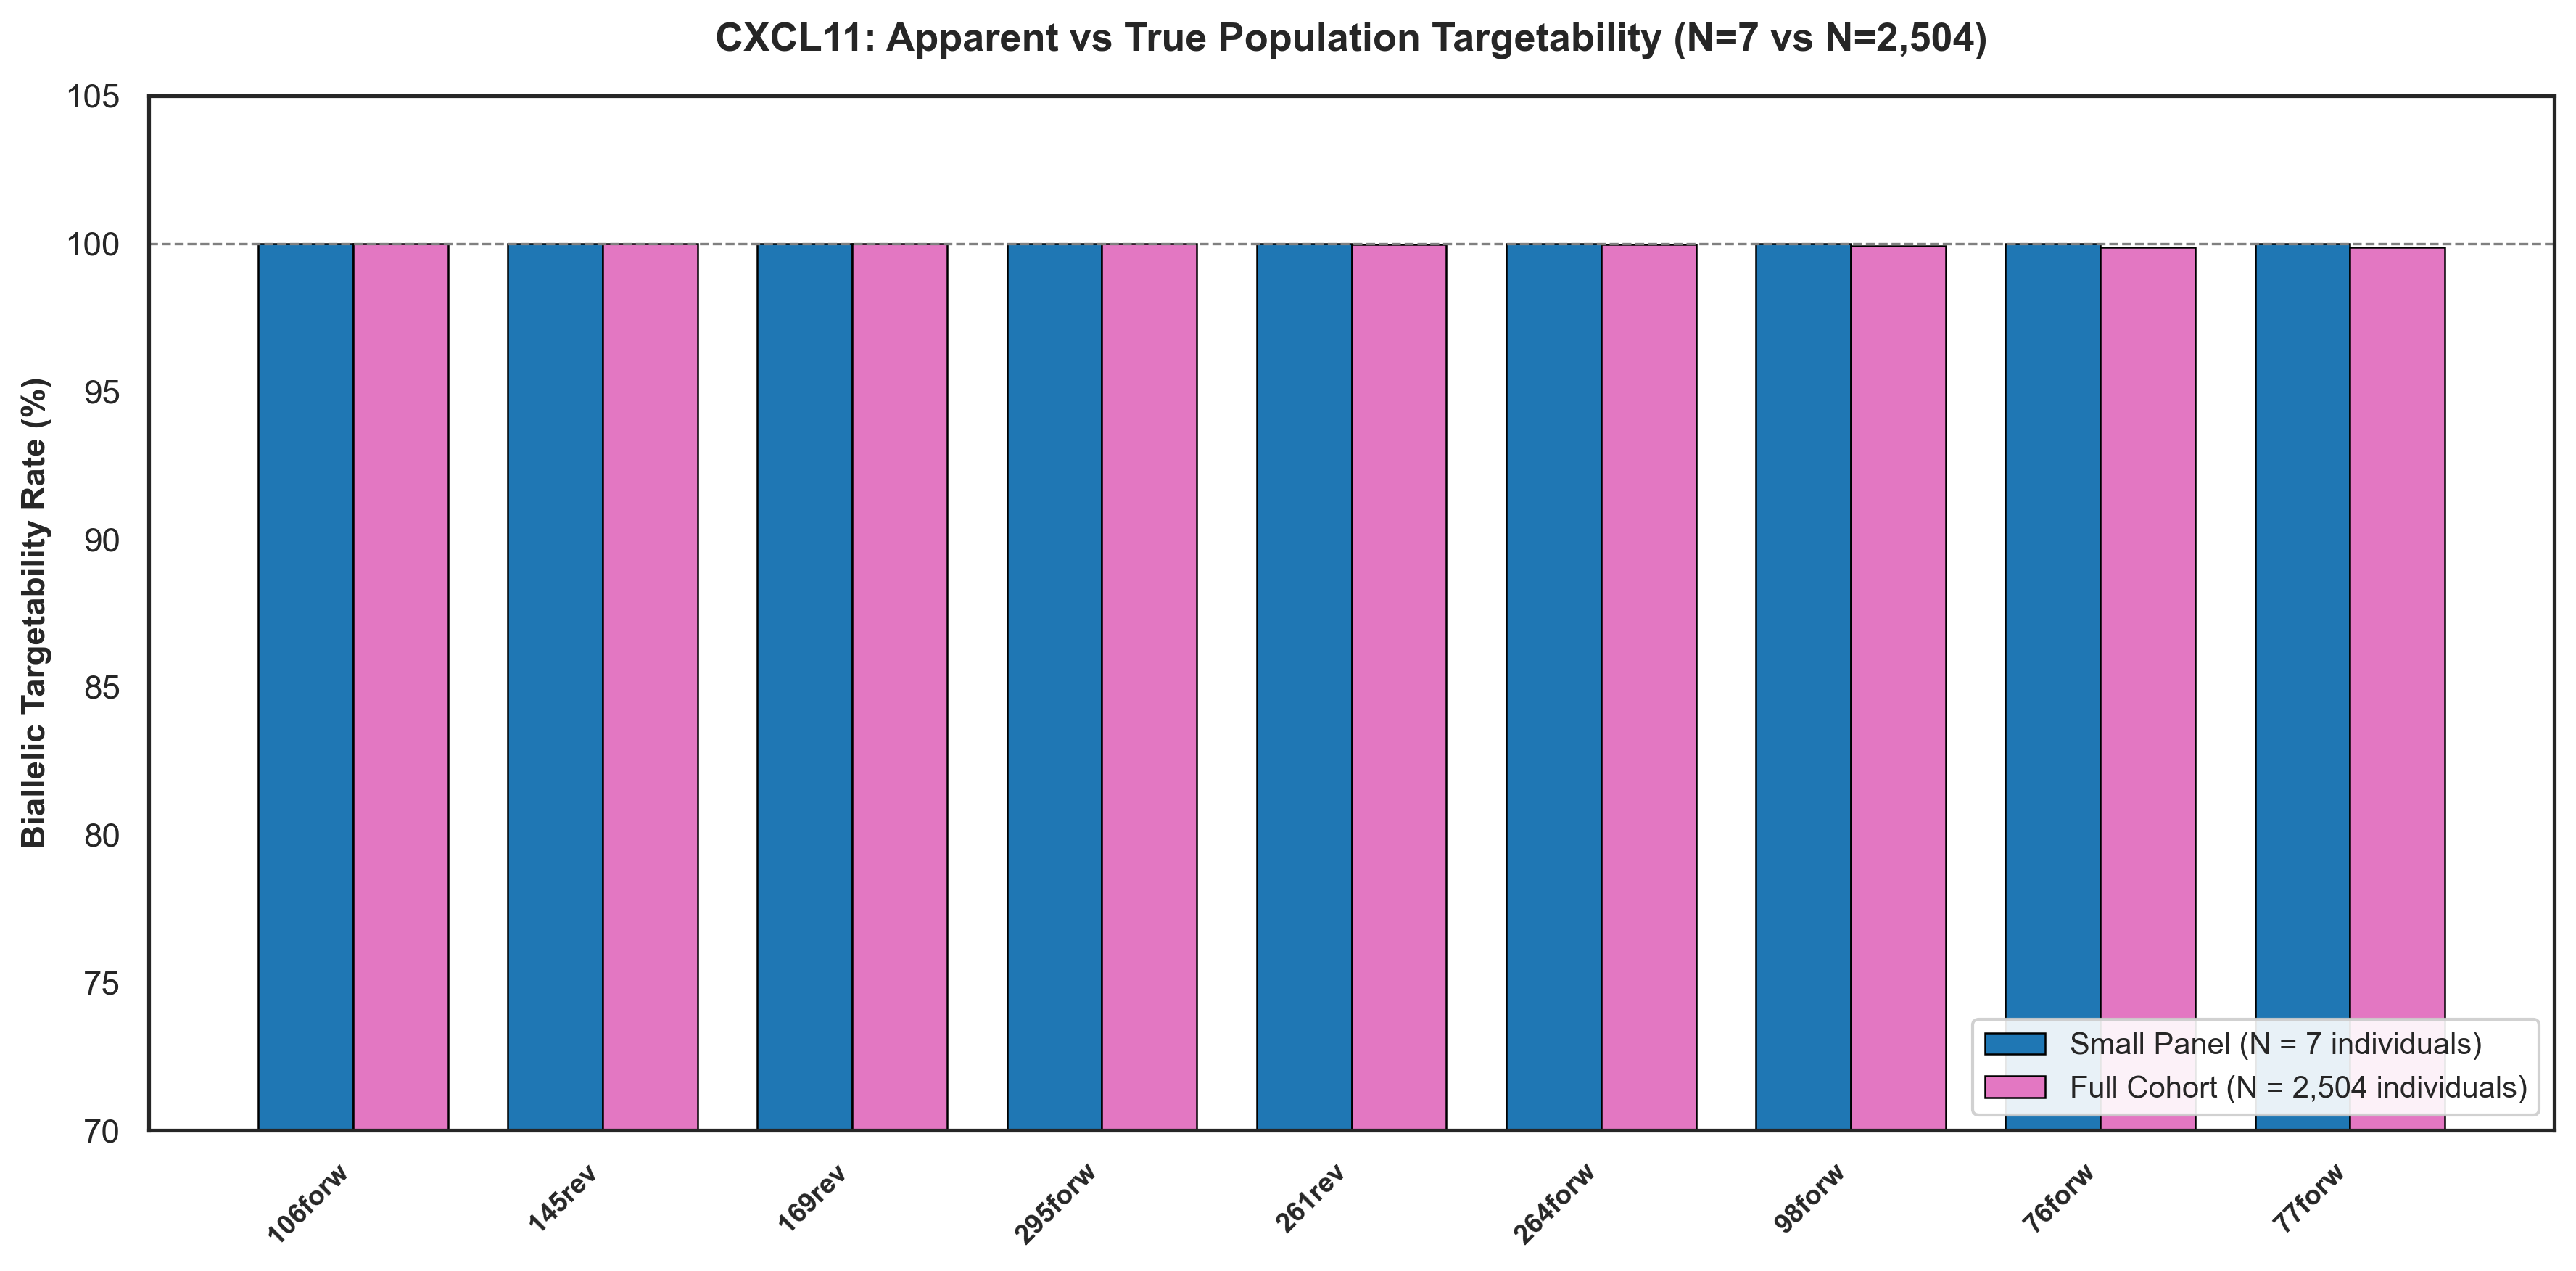

Saved: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/figures/n2504_cxcl11/task3_n2504_genome_wide_cohort_comparison_n7_vs_n2504.png


In [8]:
# 1. Ancestry Disruption Heatmap
# One gene here, so the guide id alone identifies the row and the title carries
# the gene.
ancestry_plot = ancestry_df.sort_values('guide_id').copy()
ancestry_plot['guide_label'] = list(ancestry_plot['guide_id'])
heatmap_data = ancestry_plot.set_index('guide_label')[['EUR_disruption_pct', 'AFR_disruption_pct', 'EAS_disruption_pct', 'SAS_disruption_pct', 'AMR_disruption_pct']]
# Two lines per label, matching the risk-site ancestry heatmap, so the
# column names sit flat and read the same way across both figures.
heatmap_data.columns = ['European\n(EUR)', 'African\n(AFR)', 'East Asian\n(EAS)', 'South Asian\n(SAS)', 'Admixed Amer.\n(AMR)']

plt.figure(figsize=(10, 7), dpi=300)
sns.set_theme(style="white")
ax = sns.heatmap(
    heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Disrupted Individuals (%)'},
    linewidths=0.5, linecolor='lightgray', annot_kws={'weight': 'bold'}
)
# Seaborn turns the guide ids on their side when it thinks they will not
# fit, which runs them together into one unreadable string. They are short
# enough to sit horizontally.
plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=0, fontsize=10, weight='bold')
plt.title("CXCL11: Ancestry-Stratified On-Target Disruption Rate (N = 2,504 Individuals)", fontsize=13, weight='bold', pad=15)
plt.ylabel("gRNA Identifier", fontsize=11, weight='bold')
plt.xlabel("Continental Super-Population", fontsize=11, weight='bold')
plt.tight_layout()
heatmap_fig = FIGURE_DIR / 'task3_n2504_genome_wide_ancestry_disruption_heatmap.png'
plt.savefig(heatmap_fig)
plt.show()
print(f"Saved: {heatmap_fig}")

# 2. Biallelic Penetrance Waterfall Plot
plot_df = penetrance_df.sort_values('biallelic_pass_pct', ascending=True).copy()
labels = list(plot_df['guide_id'])

plt.figure(figsize=(11, 7), dpi=300)
y_pos = np.arange(len(plot_df))
p1 = plt.barh(y_pos, plot_df['biallelic_pass_pct'], color='#2ca02c', label='Biallelic Intact (PASS: 2 Alleles)', edgecolor='black', linewidth=0.5)
p2 = plt.barh(y_pos, plot_df['heterozygous_caution_pct'], left=plot_df['biallelic_pass_pct'], color='#ff7f0e', label='Heterozygous Disrupted (CAUTION: 1 Allele)', edgecolor='black', linewidth=0.5)
p3 = plt.barh(y_pos, plot_df['homozygous_escape_fail_pct'], left=plot_df['biallelic_pass_pct'] + plot_df['heterozygous_caution_pct'], color='#d62728', label='Homozygous Escape (FAIL: 0 Alleles)', edgecolor='black', linewidth=0.5)

plt.yticks(y_pos, labels, fontsize=10, weight='bold')
plt.xlabel("Cohort Proportion (%)", fontsize=11, weight='bold')
plt.title("CXCL11: Biallelic Targetability Penetrance Across 1000 Genomes (N = 2,504)", fontsize=13, weight='bold', pad=15)
plt.xlim(0, 105)
plt.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.axvline(100, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
waterfall_fig = FIGURE_DIR / 'task3_n2504_genome_wide_biallelic_penetrance_waterfall.png'
plt.savefig(waterfall_fig)
plt.show()
print(f"Saved: {waterfall_fig}")

# 3. Cohort Comparison Plot: N=7 vs N=2504
comp_df = penetrance_df[['gene', 'guide_id', 'biallelic_pass_pct']].copy()
comp_df['n7_pass_pct'] = 100.0  # From Task 3 baseline where all 9 CXCL11 guides passed in 7/7 samples

x = np.arange(len(comp_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
rects1 = ax.bar(x - width/2, comp_df['n7_pass_pct'], width, label='Small Panel (N = 7 individuals)', color='#1f77b4', edgecolor='black', linewidth=0.6)
rects2 = ax.bar(x + width/2, comp_df['biallelic_pass_pct'], width, label='Full Cohort (N = 2,504 individuals)', color='#e377c2', edgecolor='black', linewidth=0.6)

ax.set_ylabel('Biallelic Targetability Rate (%)', fontsize=11, weight='bold')
ax.set_title('CXCL11: Apparent vs True Population Targetability (N=7 vs N=2,504)', fontsize=13, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(comp_df['guide_id'], rotation=45, ha='right', fontsize=9, weight='bold')
ax.set_ylim(70, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9, fontsize=10)
plt.tight_layout()
comp_fig = FIGURE_DIR / 'task3_n2504_genome_wide_cohort_comparison_n7_vs_n2504.png'
plt.savefig(comp_fig)
plt.show()
print(f"Saved: {comp_fig}")


## 5. Candidate Off-Target Personal Evaluation Across 2,504 Individuals

Next we evaluate whether personal genetic variants alter cleavage hazards at the candidate off-target loci CRISPOR predicted for the 9 *CXCL11* guides.

### Methodology & storage optimisation
- Candidate sites are validated against the primary reference contigs for all 22 autosomes (`NC_000001.11` through `NC_000022.11`). Sites on chromosomes X and Y are reported as not evaluated, because the 1000 Genomes 20190312 release provides no usable genotypes there.
- Testing every analysable locus against all 2,504 individuals $\times$ 2 haplotypes would run to millions of evaluation events, and the large majority of candidate sites carry no variant in any individual, so writing out those identical reference rows would produce an unmanageable table.
- Instead we apply a variant filter:
  1. Query whether any variant record overlaps the candidate site in the cohort VCF. A locus with no overlapping record in any individual is skipped.
  2. For the loci that do carry variants, evaluate the genotypes of all 2,504 individuals and record every variant-altered cleavage hazard (`INCREASED`, `DECREASED`, `CREATED` or `REMOVED`).
  3. Save the filtered table of personalised off-target events and compute individual risk summaries.

**Every number in this section is computed below rather than quoted here** — the reconstruction window, the per-guide candidate-site denominators, and the haplotypes actually evaluated. Earlier drafts of this notebook carried hard-coded counts that went stale when the guide pool changed.

In [9]:
def read_crispor_xls(path, gene):
    sheet = xlrd.open_workbook(str(path)).sheet_by_index(0)
    header = next((i for i in range(sheet.nrows) if str(sheet.cell_value(i, 0)).strip() == 'guideId'), None)
    if header is None:
        raise ValueError(f'guideId header not found in {path.name}')
    names = [str(x).strip() for x in sheet.row_values(header)]
    records = [dict(zip(names, sheet.row_values(i))) for i in range(header + 1, sheet.nrows) if str(sheet.cell_value(i, 0)).strip()]
    return pd.DataFrame(records).rename(columns={
        'guideId': 'guide_id', 'guideSeq': 'guide_sequence', 'offtargetSeq': 'offtarget_sequence',
        'mismatchCount': 'reference_mismatch_count_crispor', 'mitOfftargetScore': 'reference_mit_score',
        'cfdOfftargetScore': 'reference_cfd_score', 'locusDesc': 'locus_description'
    }).assign(gene=gene, source_file=path.name)

all_offtargets = pd.concat([read_crispor_xls(path, gene) for gene, path in OFFTARGET_XLS.items()], ignore_index=True)
for col in ['guide_id', 'guide_sequence', 'offtarget_sequence', 'chrom', 'locus_description']:
    all_offtargets[col] = all_offtargets[col].astype(str).str.strip()
all_offtargets['strand_raw'] = all_offtargets['strand'].astype(str).str.strip()
all_offtargets['strand'] = all_offtargets['strand_raw'].str.extract(r'^([+-])', expand=False)
all_offtargets['chrom'] = all_offtargets['chrom'].map(canonical_chromosome)
all_offtargets['start_raw'] = pd.to_numeric(all_offtargets['start'], errors='raise').astype(int)
all_offtargets['end_raw'] = pd.to_numeric(all_offtargets['end'], errors='raise').astype(int)

# Filter by the 9 eligible CXCL11 guides
pairs = set(map(tuple, guides[['gene', 'guide_id']].to_numpy()))
off_targets = all_offtargets.loc[all_offtargets.apply(lambda row: (row['gene'], row['guide_id']) in pairs, axis=1)].copy()

def resolve_site(row):
    chrom = row['chrom']
    fasta_chrom = analyzer.fasta_contigs.get(chrom)
    if not fasta_chrom:
        return pd.Series({'fasta_chrom': pd.NA, 'start_1based': pd.NA, 'end_1based': pd.NA, 'reference_valid': False, 'site_validation_status': 'REFERENCE_CONTIG_UNAVAILABLE'})
    candidates = [(row['start_raw'], row['end_raw'], row['start_raw'] - 1, row['end_raw']),
                  (row['start_raw'] + 1, row['end_raw'] + 1, row['start_raw'], row['end_raw'] + 1)]
    matches = []
    for start, end, fetch_start, fetch_end in candidates:
        sequence = analyzer.reference.fetch(fasta_chrom, fetch_start, fetch_end).upper()
        if orient_sequence(sequence, row['strand']) == row['offtarget_sequence']:
            matches.append((start, end))
    if len(matches) != 1:
        return pd.Series({'fasta_chrom': chrom, 'start_1based': pd.NA, 'end_1based': pd.NA, 'reference_valid': False,
                          'site_validation_status': 'SEQUENCE_NOT_MATCHED' if not matches else 'COORDINATE_AMBIGUOUS'})
    return pd.Series({'fasta_chrom': chrom, 'start_1based': matches[0][0], 'end_1based': matches[0][1],
                      'reference_valid': True, 'site_validation_status': 'VALIDATED'})

site_mapping = off_targets.apply(resolve_site, axis=1)
off_targets = pd.concat([off_targets.reset_index(drop=True), site_mapping.reset_index(drop=True)], axis=1)
off_targets['offtarget_id'] = [f'OT{i+1:05d}' for i in range(len(off_targets))]
validated_offtargets = off_targets.loc[off_targets['reference_valid']].copy()
validated_offtargets['start_1based'] = validated_offtargets['start_1based'].astype(int)
validated_offtargets['end_1based'] = validated_offtargets['end_1based'].astype(int)

validated_tsv = TABLE_DIR / 'task3_n2504_genome_wide_selected_crispor_offtargets_validated.tsv'
validated_offtargets.to_csv(validated_tsv, sep='\t', index=False)
print(f"Validated candidate off-targets saved to: {validated_tsv} ({len(validated_offtargets)} sites)")

# Screen analysable off-targets across 2,504 individuals.
#
# Two separate things have to be true before a site can be evaluated: its
# chromosome needs a VCF, and the site needs to lie inside the regions that VCF
# was actually built from. The prepared VCFs hold only the windows listed in
# task3_offtarget_regions.bed, so a site outside that list has no records for a
# reason that has nothing to do with the cohort. Without this check it is
# indistinguishable from a site where all 2,504 individuals match the reference,
# and the guide owning it is reported as clean.
REGION_BED = TASK3 / 'inputs' / 'task3_offtarget_regions.bed'
region_index = {}
for line in REGION_BED.read_text().splitlines():
    if not line or line.startswith('#'):
        continue
    fields = line.split('\t')
    region_index.setdefault(canonical_chromosome(fields[0]), []).append(
        (int(fields[1]) + 1, int(fields[2])))

def site_in_prepared_regions(chrom, start, end):
    return any(a <= end and start <= b for a, b in region_index.get(str(chrom), []))

has_vcf = validated_offtargets['chrom'].astype(str).isin(analyzer.vcfs.keys())
in_regions = pd.Series(
    [site_in_prepared_regions(r.chrom, r.start_1based, r.end_1based)
     for r in validated_offtargets.itertuples()],
    index=validated_offtargets.index)

is_analysable = has_vcf & in_regions
validated_offtargets['evaluation_status'] = np.select(
    [is_analysable, ~has_vcf],
    ['ANALYSABLE', 'NO_VCF_FOR_CHROMOSOME'],
    default='OUTSIDE_PREPARED_REGIONS')
analysable = validated_offtargets[is_analysable].copy()
not_evaluated = validated_offtargets[~is_analysable].copy()

# Fail rather than under-report. The guide pool and the region list are built by
# separate steps, and the region list going stale when the pool is widened is
# silent in every downstream number.
stale = (
    validated_offtargets[has_vcf]
    .assign(covered=in_regions[has_vcf])
    .groupby('guide_id')['covered']
    .agg(sites='size', covered='sum')
)
stale['uncovered'] = stale['sites'] - stale['covered']
stale = stale[stale['uncovered'] > 0]
if len(stale):
    display(Markdown('**Guides with candidate sites outside the prepared VCF regions**'))
    display(stale)
    raise RuntimeError(
        f'{REGION_BED.name} does not cover every guide being analysed: '
        f'{int(stale["uncovered"].sum())} candidate sites across {len(stale)} guides were '
        'never downloaded. Regenerate the region list from the current guide pool and '
        'rebuild the VCFs (utils/prepare_n2504_vcfs.py), otherwise these guides are '
        'reported as clean because nothing was looked at.'
    )

display(Markdown(
    f'**Candidate off-target coverage.** CRISPOR returned `{len(off_targets)}` candidates for '
    f'the `{len(guides)}` CXCL11 guides, of which `{len(validated_offtargets)}` reproduce the '
    f'reported sequence in GRCh38 and are validated. `{len(analysable)}` of those lie on a '
    f'chromosome with a usable VCF and are analysable; `{len(not_evaluated)}` are not evaluated.  \n'
    f'Each candidate site is reconstructed with a `{analyzer.pad}` bp window either side, the '
    f'same window used for the on-target sites above, so the longest detectable deletion '
    f'reaching in from outside the site is bounded identically.'
))

if len(not_evaluated):
    display(Markdown('**Validated candidates not evaluated, by reason**'))
    display(not_evaluated.groupby(['evaluation_status', 'chrom'])
            .size().rename('candidate_sites').to_frame())

altered_events = []
RISK_EFFECTS = ['INCREASED', 'DECREASED', 'CREATED', 'REMOVED', 'UNRESOLVED']
sample_risk_counts = {s: {e: 0 for e in RISK_EFFECTS} for s in SAMPLES}

# Denominators. Percentages below are over every haplotype evaluated, not only
# the ones that produced an event, and sites with no overlapping variant are
# counted rather than silently skipped.
evaluated_haplotypes = 0
unresolved_haplotypes = 0
sites_without_variants = 0
# Per-guide tally of the sites that actually reached genotype evaluation, for
# the denominator table below.
sites_with_variants_by_guide = {g: 0 for g in guides['guide_id']}

for _, site in analysable.iterrows():
    chrom = str(site['chrom'])
    start = int(site['start_1based'])
    end = int(site['end_1based'])
    strand = site['strand']
    guide_20mer = site['guide_sequence'][:20]
    
    records = analyzer._get_overlapping_records(
        analyzer.vcfs[chrom], analyzer.vcf_contig(chrom), start, end
    )

    if not records:
        sites_without_variants += 1
        continue

    sites_with_variants_by_guide[site['guide_id']] += 1
        
    ref_seq = analyzer.reference.fetch(analyzer.fasta_contigs.get(chrom, chrom), start - 1, end).upper()
    ref_site = orient_sequence(ref_seq, strand)
    
    for sample_id in SAMPLES:
        a1, a2, rec = analyzer.reconstruct_alleles(chrom, start, end, sample_id)
        for hap, allele in enumerate([a1, a2], 1):
            alt_site = orient_sequence(allele, strand)
            effect = analyzer.classify_off_target(guide_20mer, ref_site, alt_site)
            evaluated_haplotypes += 1
            if effect == 'UNRESOLVED':
                unresolved_haplotypes += 1
            if effect != 'UNCHANGED':
                altered_events.append({
                    'sample_id': sample_id,
                    'gene': site['gene'],
                    'guide_id': site['guide_id'],
                    'offtarget_id': site['offtarget_id'],
                    'chrom': chrom,
                    'start_1based': start,
                    'end_1based': end,
                    'strand': strand,
                    'haplotype': hap,
                    'reconstruction_status': rec,
                    'ref_site_23mer': ref_site,
                    'personalised_site_23mer': alt_site,
                    'offtarget_effect': effect,
                    'super_population': sample_meta_dict[sample_id]['super_population']
                })
                if effect in sample_risk_counts[sample_id]:
                    sample_risk_counts[sample_id][effect] += 1

altered_df = pd.DataFrame(altered_events)
altered_tsv = TABLE_DIR / 'task3_n2504_genome_wide_personalised_offtargets.tsv.gz'
altered_df.to_csv(altered_tsv, sep='\t', index=False, compression={'method': 'gzip', 'mtime': 0})
print(f"Altered off-target events saved to: {altered_tsv} ({len(altered_df)} non-reference events)")
display(altered_df['offtarget_effect'].value_counts().reset_index(name='Observed Events in N=2,504'))

# Per-guide candidate-site denominators. The nine guides carry very unequal
# off-target burdens, so the event counts below are only readable against the
# number of sites each guide contributed.
per_guide_sites = (
    validated_offtargets.assign(analysable=is_analysable)
    .groupby('guide_id')
    .agg(validated_sites=('offtarget_id', 'size'),
         analysable_sites=('analysable', 'sum'))
    .reindex(list(guides['guide_id']))
    .fillna(0)
    .astype(int)
)
per_guide_sites['not_evaluated_sites'] = (
    per_guide_sites['validated_sites'] - per_guide_sites['analysable_sites'])
per_guide_sites['sites_with_variants'] = (
    pd.Series(sites_with_variants_by_guide).reindex(per_guide_sites.index).fillna(0).astype(int))
per_guide_sites['sites_without_variants'] = (
    per_guide_sites['analysable_sites'] - per_guide_sites['sites_with_variants'])
per_guide_sites = per_guide_sites.sort_values('analysable_sites', ascending=False)
per_guide_sites.to_csv(
    TABLE_DIR / 'task3_n2504_genome_wide_candidate_sites_by_guide.tsv', sep='\t')
display(Markdown('**Candidate off-target sites per CXCL11 guide**'))
display(per_guide_sites)

display(Markdown(
    f'Analysable sites: `{len(analysable)}` '
    f'(`{sites_without_variants}` carried no variant in any individual).  \n'
    f'Haplotypes evaluated: `{evaluated_haplotypes:,}`, of which '
    f'`{unresolved_haplotypes:,}` (`{unresolved_haplotypes / max(evaluated_haplotypes, 1) * 100:.3f}%`) '
    f'could not be determined.  \n'
    f'All percentages below are over the `{evaluated_haplotypes:,}` evaluated haplotypes.'
))


Validated candidate off-targets saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_selected_crispor_offtargets_validated.tsv (1810 sites)


**Candidate off-target coverage.** CRISPOR returned `1814` candidates for the `9` CXCL11 guides, of which `1810` reproduce the reported sequence in GRCh38 and are validated. `1703` of those lie on a chromosome with a usable VCF and are analysable; `107` are not evaluated.  
Each candidate site is reconstructed with a `50` bp window either side, the same window used for the on-target sites above, so the longest detectable deletion reaching in from outside the site is bounded identically.

**Validated candidates not evaluated, by reason**

candidate_sites
evaluation_status     chrom                 
NO_VCF_FOR_CHROMOSOME X                   85
                      Y                   22

Altered off-target events saved to: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/tables/n2504_cxcl11/task3_n2504_genome_wide_personalised_offtargets.tsv.gz (91615 non-reference events)


,offtarget_effect,"Observed Events in N=2,504"
0,DECREASED,67630
1,UNRESOLVED,12406
2,REMOVED,9602
3,INCREASED,1977


**Candidate off-target sites per CXCL11 guide**

,validated_sites,analysable_sites,not_evaluated_sites,sites_with_variants,sites_without_variants
guide_id,,,,,
261rev,294,278,16,122,156
145rev,281,266,15,118,148
169rev,240,225,15,105,120
77forw,219,204,15,105,99
98forw,189,179,10,86,93
295forw,165,156,9,58,98
76forw,167,152,15,75,77
264forw,152,148,4,76,72
106forw,103,95,8,41,54


Analysable sites: `1703` (`917` carried no variant in any individual).  
Haplotypes evaluated: `3,936,288`, of which `12,406` (`0.315%`) could not be determined.  
All percentages below are over the `3,936,288` evaluated haplotypes.

offtarget_effect,DECREASED,INCREASED,REMOVED,UNRESOLVED
guide_id,,,,
106forw,1045,3,17,4
145rev,11425,238,1065,397
169rev,4451,39,1420,4918
261rev,5326,248,2273,560
264forw,17487,110,409,47
295forw,4678,19,37,10
76forw,2262,149,784,7
77forw,11857,158,1497,6316
98forw,9099,1013,2100,147


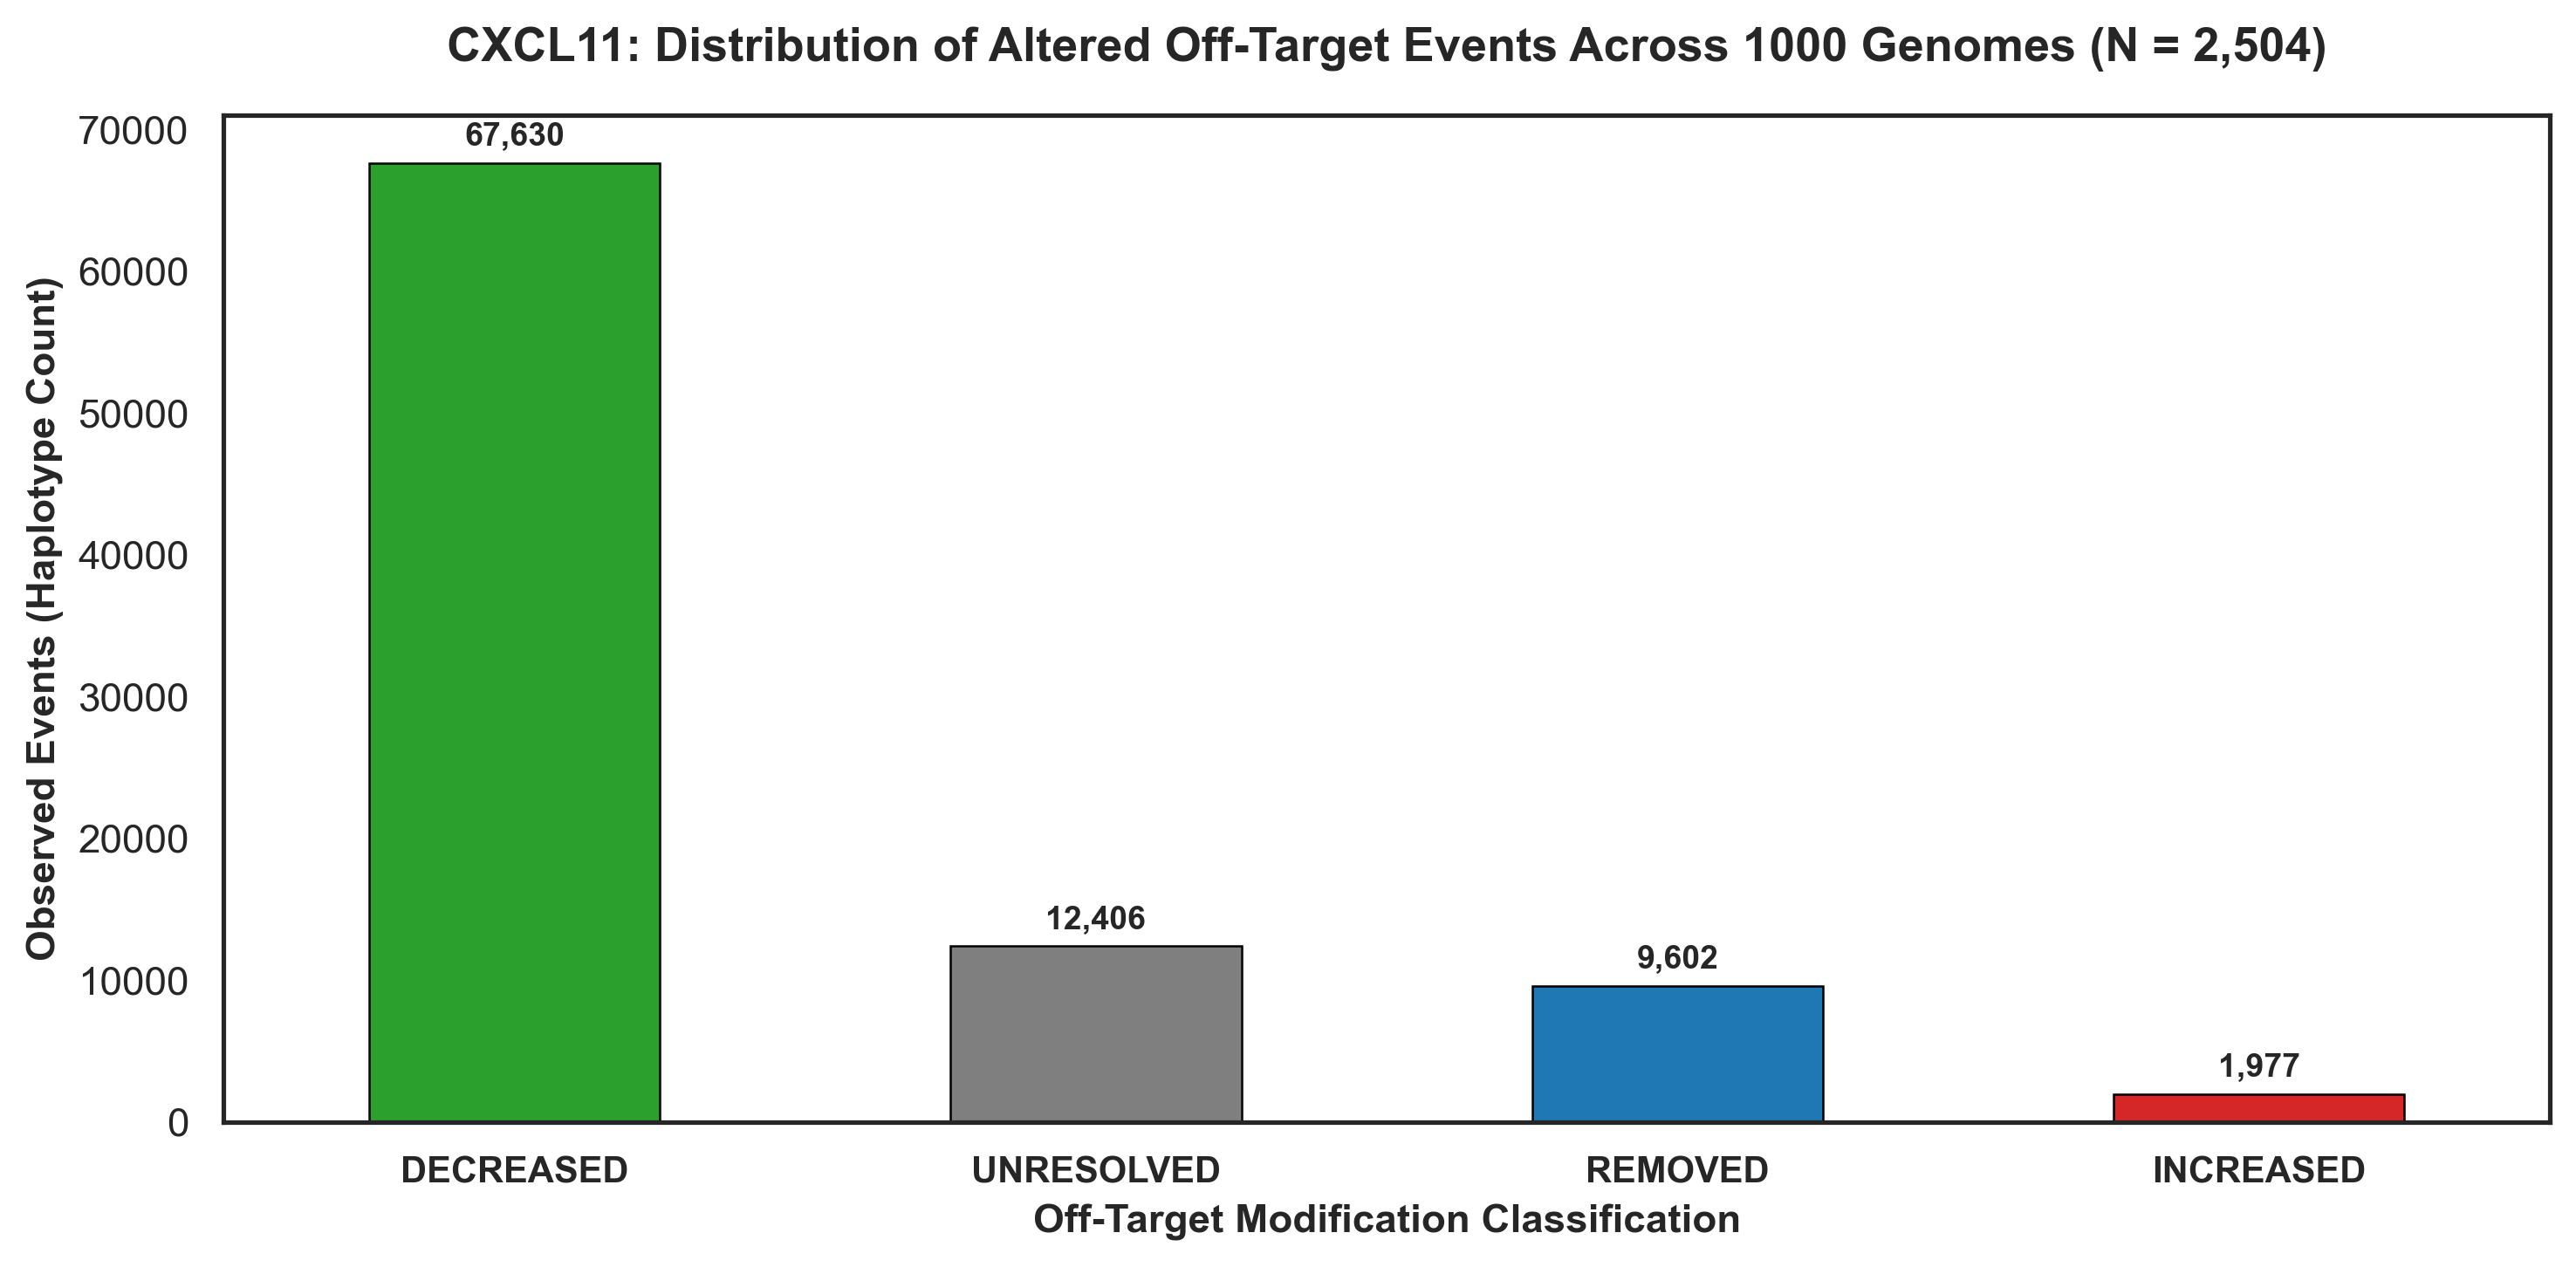

Saved: /Users/katrinamcmiddlin/repos/ifn646-task3/Task3/results/figures/n2504_cxcl11/task3_n2504_genome_wide_offtarget_risk_breakdown.png


In [10]:
# Summarize off-target risk modification by guide across cohort
if len(altered_df) > 0:
    guide_ot_summary = altered_df.groupby(['guide_id', 'offtarget_effect']).size().unstack(fill_value=0)
    display(guide_ot_summary)
    
    # Plot Off-Target Effect Breakdown
    plt.figure(figsize=(10, 5), dpi=300)
    effect_counts = altered_df['offtarget_effect'].value_counts()
    colors = {'DECREASED': '#2ca02c', 'INCREASED': '#d62728', 'REMOVED': '#1f77b4',
              'UNRESOLVED': '#7f7f7f', 'CREATED': '#ff7f0e'}
    bar_colors = [colors.get(e, '#333333') for e in effect_counts.index]
    
    ax = effect_counts.plot(kind='bar', color=bar_colors, edgecolor='black', linewidth=0.6)
    plt.title("CXCL11: Distribution of Altered Off-Target Events Across 1000 Genomes (N = 2,504)", fontsize=13, weight='bold', pad=15)
    plt.xlabel("Off-Target Modification Classification", fontsize=11, weight='bold')
    plt.ylabel("Observed Events (Haplotype Count)", fontsize=11, weight='bold')
    plt.xticks(rotation=0, fontsize=10, weight='bold')
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points', weight='bold')
    plt.tight_layout()
    ot_fig = FIGURE_DIR / 'task3_n2504_genome_wide_offtarget_risk_breakdown.png'
    plt.savefig(ot_fig)
    plt.show()
    print(f"Saved: {ot_fig}")


**Off-target events by chromosome (haplotype observations)**

offtarget_effect,DECREASED,INCREASED,REMOVED,UNRESOLVED
chrom,,,,
1,703,147,39,266
2,6457,70,130,5135
3,3381,1012,242,8
4,8031,101,24,126
5,8287,100,164,597
6,54,29,5,567
7,3183,26,1630,437
8,2262,38,3,22
9,10640,7,18,3


**Risk-increasing observations: `1,977`**

observations  sites  individuals  \
gene   guide_id                                     
CXCL11 106forw              3      3            3   
       145rev             238     10          228   
       169rev              39      3           39   
       261rev             248      5          229   
       264forw            110      5          104   
       295forw             19      8           19   
       76forw             149      9          145   
       77forw             158     12          152   
       98forw            1013      4          889   

                                          chromosomes  
gene   guide_id                                        
CXCL11 106forw                              2, 13, 21  
       145rev                1, 2, 4, 6, 7, 8, 11, 13  
       169rev                                   1, 11  
       261rev                        2, 4, 14, 20, 21  
       264forw                        1, 2, 7, 11, 12  
       295forw                         1, 2, 3, 4, 12  
       76forw             1, 5, 9, 15, 16, 19, 20, 21  
       77forw    1, 2, 3, 5, 8, 9, 11, 12, 16, 18, 21  
       98forw                                 1, 3, 8

/Users/katrinamcmiddlin/repos/ifn646-task3/Task3/utils/variant_utils.py:484: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.95))


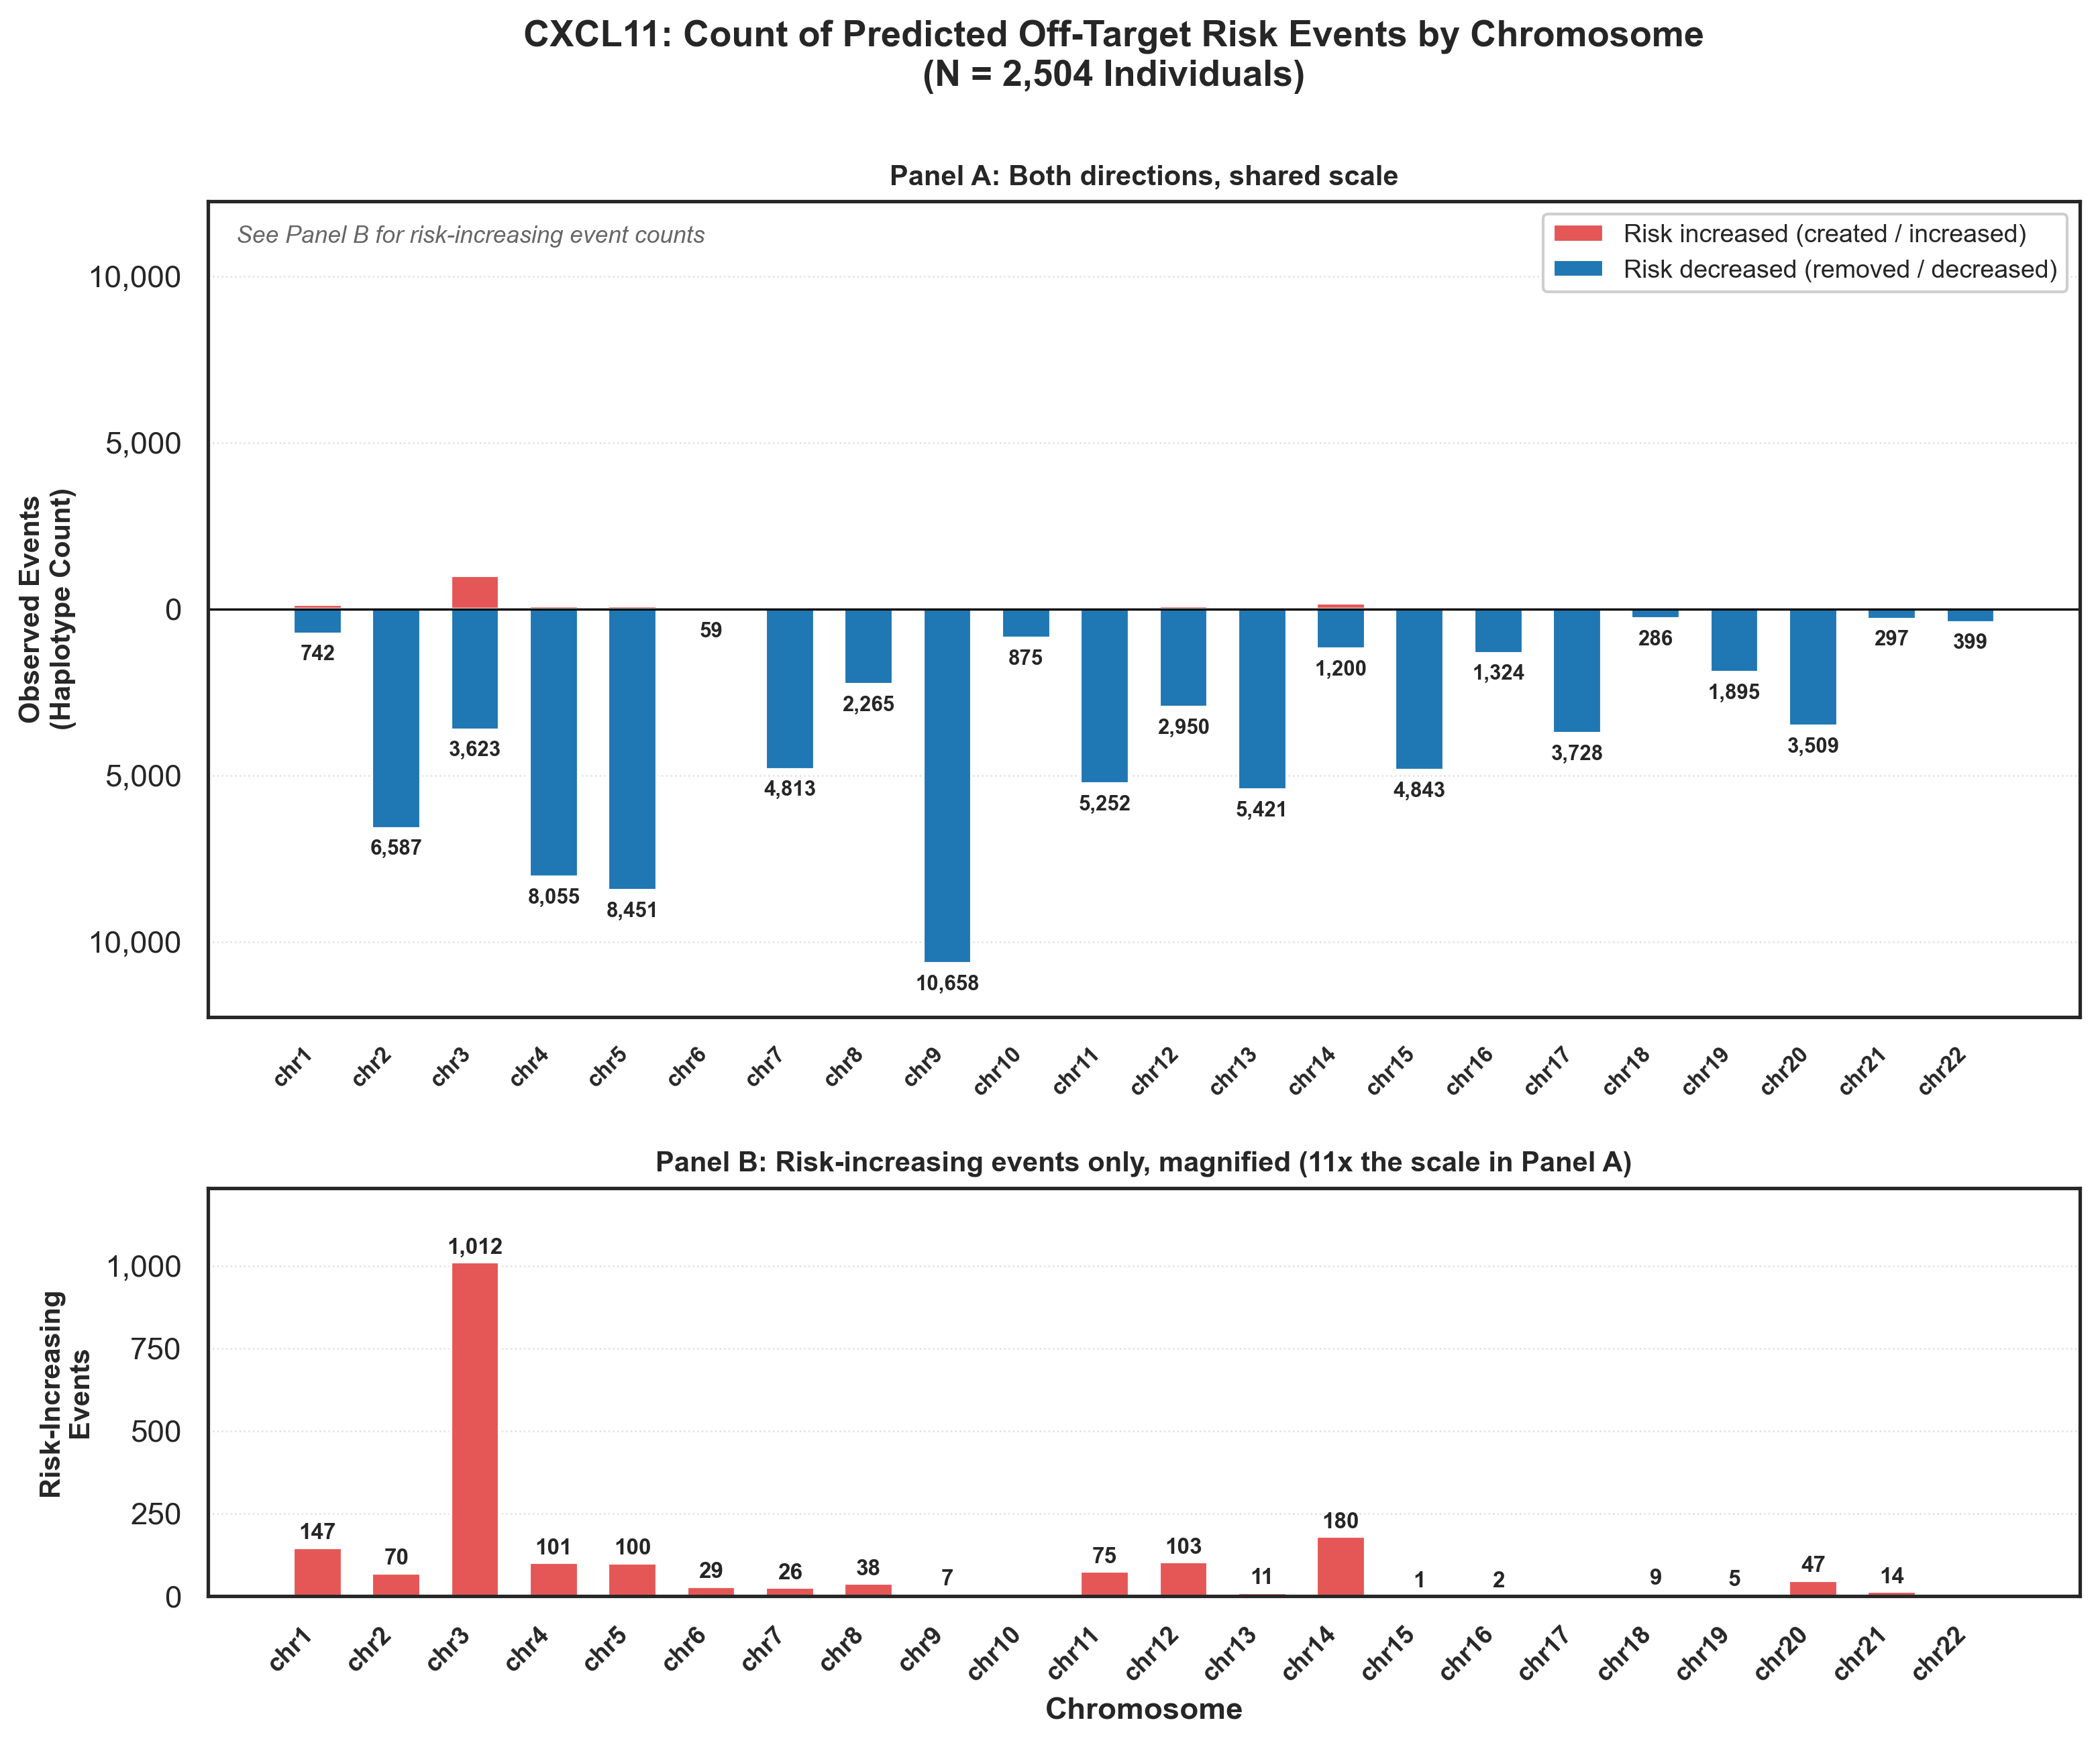

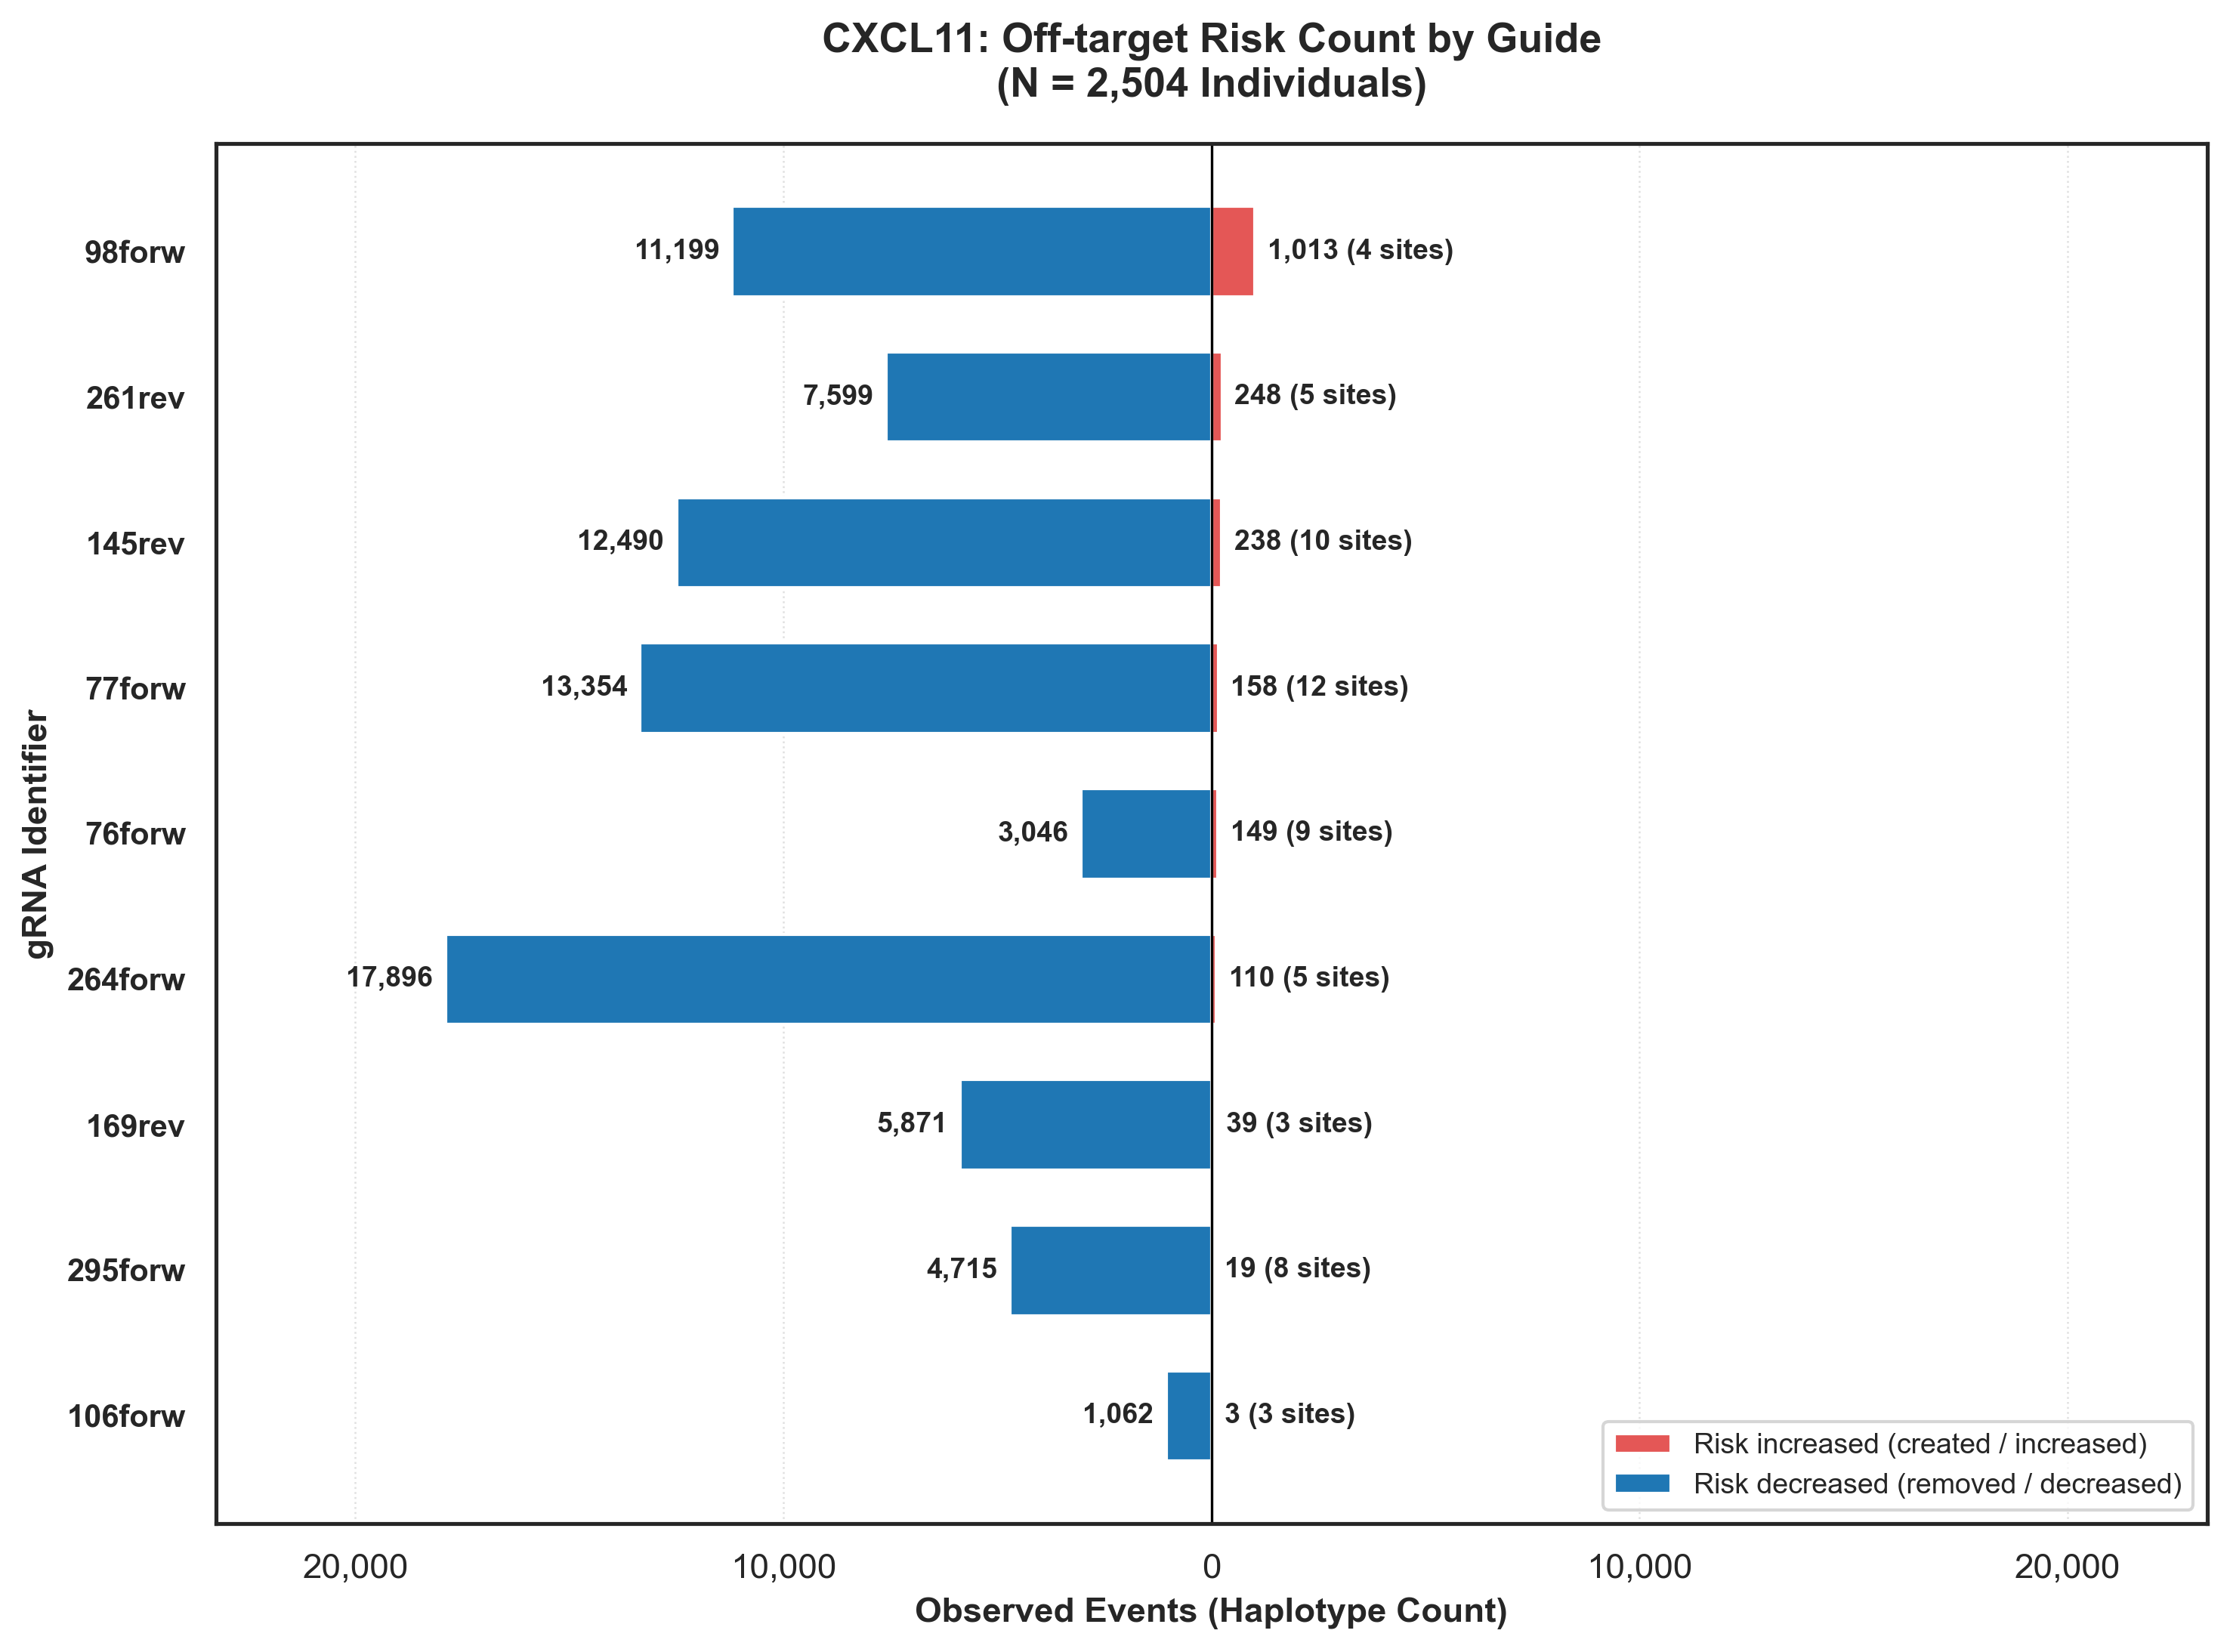

**Risk-increasing candidate sites: `59`**

,gene,guide_id,offtarget_id,chrom,start_1based,observations,carriers,carrier_pct,strand,locus_description,reference_mismatch_count_crispor,reference_mit_score,reference_cfd_score,EUR_carrier_pct,AFR_carrier_pct,EAS_carrier_pct,SAS_carrier_pct,AMR_carrier_pct
0,CXCL11,98forw,OT01626,3,120777182,1010,888,35.463,+,intron:GTF2E1,3.0,0.186459,0.000000,55.159,32.727,23.810,26.994,40.922
1,CXCL11,261rev,OT01305,14,62312475,180,163,6.510,-,intergenic:LINC00644-KCNH5,4.0,1.278707,0.270130,0.198,23.485,0.000,0.000,2.017
2,CXCL11,77forw,OT01212,5,109357617,98,95,3.794,+,intron:PJA2,4.0,0.024282,0.045085,10.516,0.758,0.595,2.863,5.764
3,CXCL11,76forw,OT00582,1,184150596,96,94,3.754,+,intergenic:TSEN15-Y_RNA,4.0,0.013652,0.099946,1.984,11.515,0.000,0.204,2.017
4,CXCL11,264forw,OT00188,12,119942673,99,94,3.754,-,intergenic:AC004813.1-CCDC64,4.0,0.002613,0.010796,0.198,13.485,0.000,0.204,0.865
5,CXCL11,145rev,OT01022,4,70324276,88,87,3.474,-,intergenic:CSN3-CABS1,4.0,0.090605,0.033939,10.516,0.606,0.000,2.658,4.899
6,CXCL11,145rev,OT00884,11,117452463,61,58,2.316,-,intron:DSCAML1,4.0,0.669827,0.328858,0.992,0.000,10.119,0.409,0.000
7,CXCL11,261rev,OT01404,2,240300874,44,43,1.717,+,intergenic:U3-GPC1,4.0,0.062559,0.066370,0.000,0.000,2.183,6.544,0.000
8,CXCL11,169rev,OT00824,1,148254985,37,37,1.478,+,intergenic:RP4-565E6.1-RNU1-120P,4.0,0.100627,0.012732,1.389,3.030,0.000,1.431,0.865
9,CXCL11,76forw,OT00628,20,3995047,36,35,1.398,+,intron:RNF24,4.0,0.035711,0.034325,4.563,0.303,0.000,0.409,2.305


**Risk-increasing observations per guide, by chromosome**

chr1  chr2  chr3  chr4  chr5  chr6  chr7  chr8  chr9  chr11  \
gene   guide_id                                                                
CXCL11 98forw       1     0  1010     0     0     0     0     2     0      0   
       261rev       0    44     0     7     0     0     0     0     0      0   
       145rev       1    21     0    88     0    29    25     3     0     61   
       77forw       1     1     1     0    99     0     0    33     2      6   
       76forw      96     0     0     0     1     0     0     0     5      0   
       264forw      2     1     0     0     0     0     1     0     0      7   
       169rev      38     0     0     0     0     0     0     0     0      1   
       295forw      8     2     1     6     0     0     0     0     0      0   
       106forw      0     1     0     0     0     0     0     0     0      0   

                 chr12  chr13  chr14  chr15  chr16  chr18  chr19  chr20  \
gene   guide_id                                                           
CXCL11 98forw        0      0      0      0      0      0      0      0   
       261rev        0      0    180      0      0      0      0     11   
       145rev        0     10      0      0      0      0      0      0   
       77forw        2      0      0      0      1      9      0      0   
       76forw        0      0      0      1      1      0      5     36   
       264forw      99      0      0      0      0      0      0      0   
       169rev        0      0      0      0      0      0      0      0   
       295forw       2      0      0      0      0      0      0      0   
       106forw       0      1      0      0      0      0      0      0   

                 chr21  total  
gene   guide_id                
CXCL11 98forw        0   1013  
       261rev        6    248  
       145rev        0    238  
       77forw        3    158  
       76forw        4    149  
       264forw       0    110  
       169rev        0     39  
       295forw       0     19  
       106forw       1      3

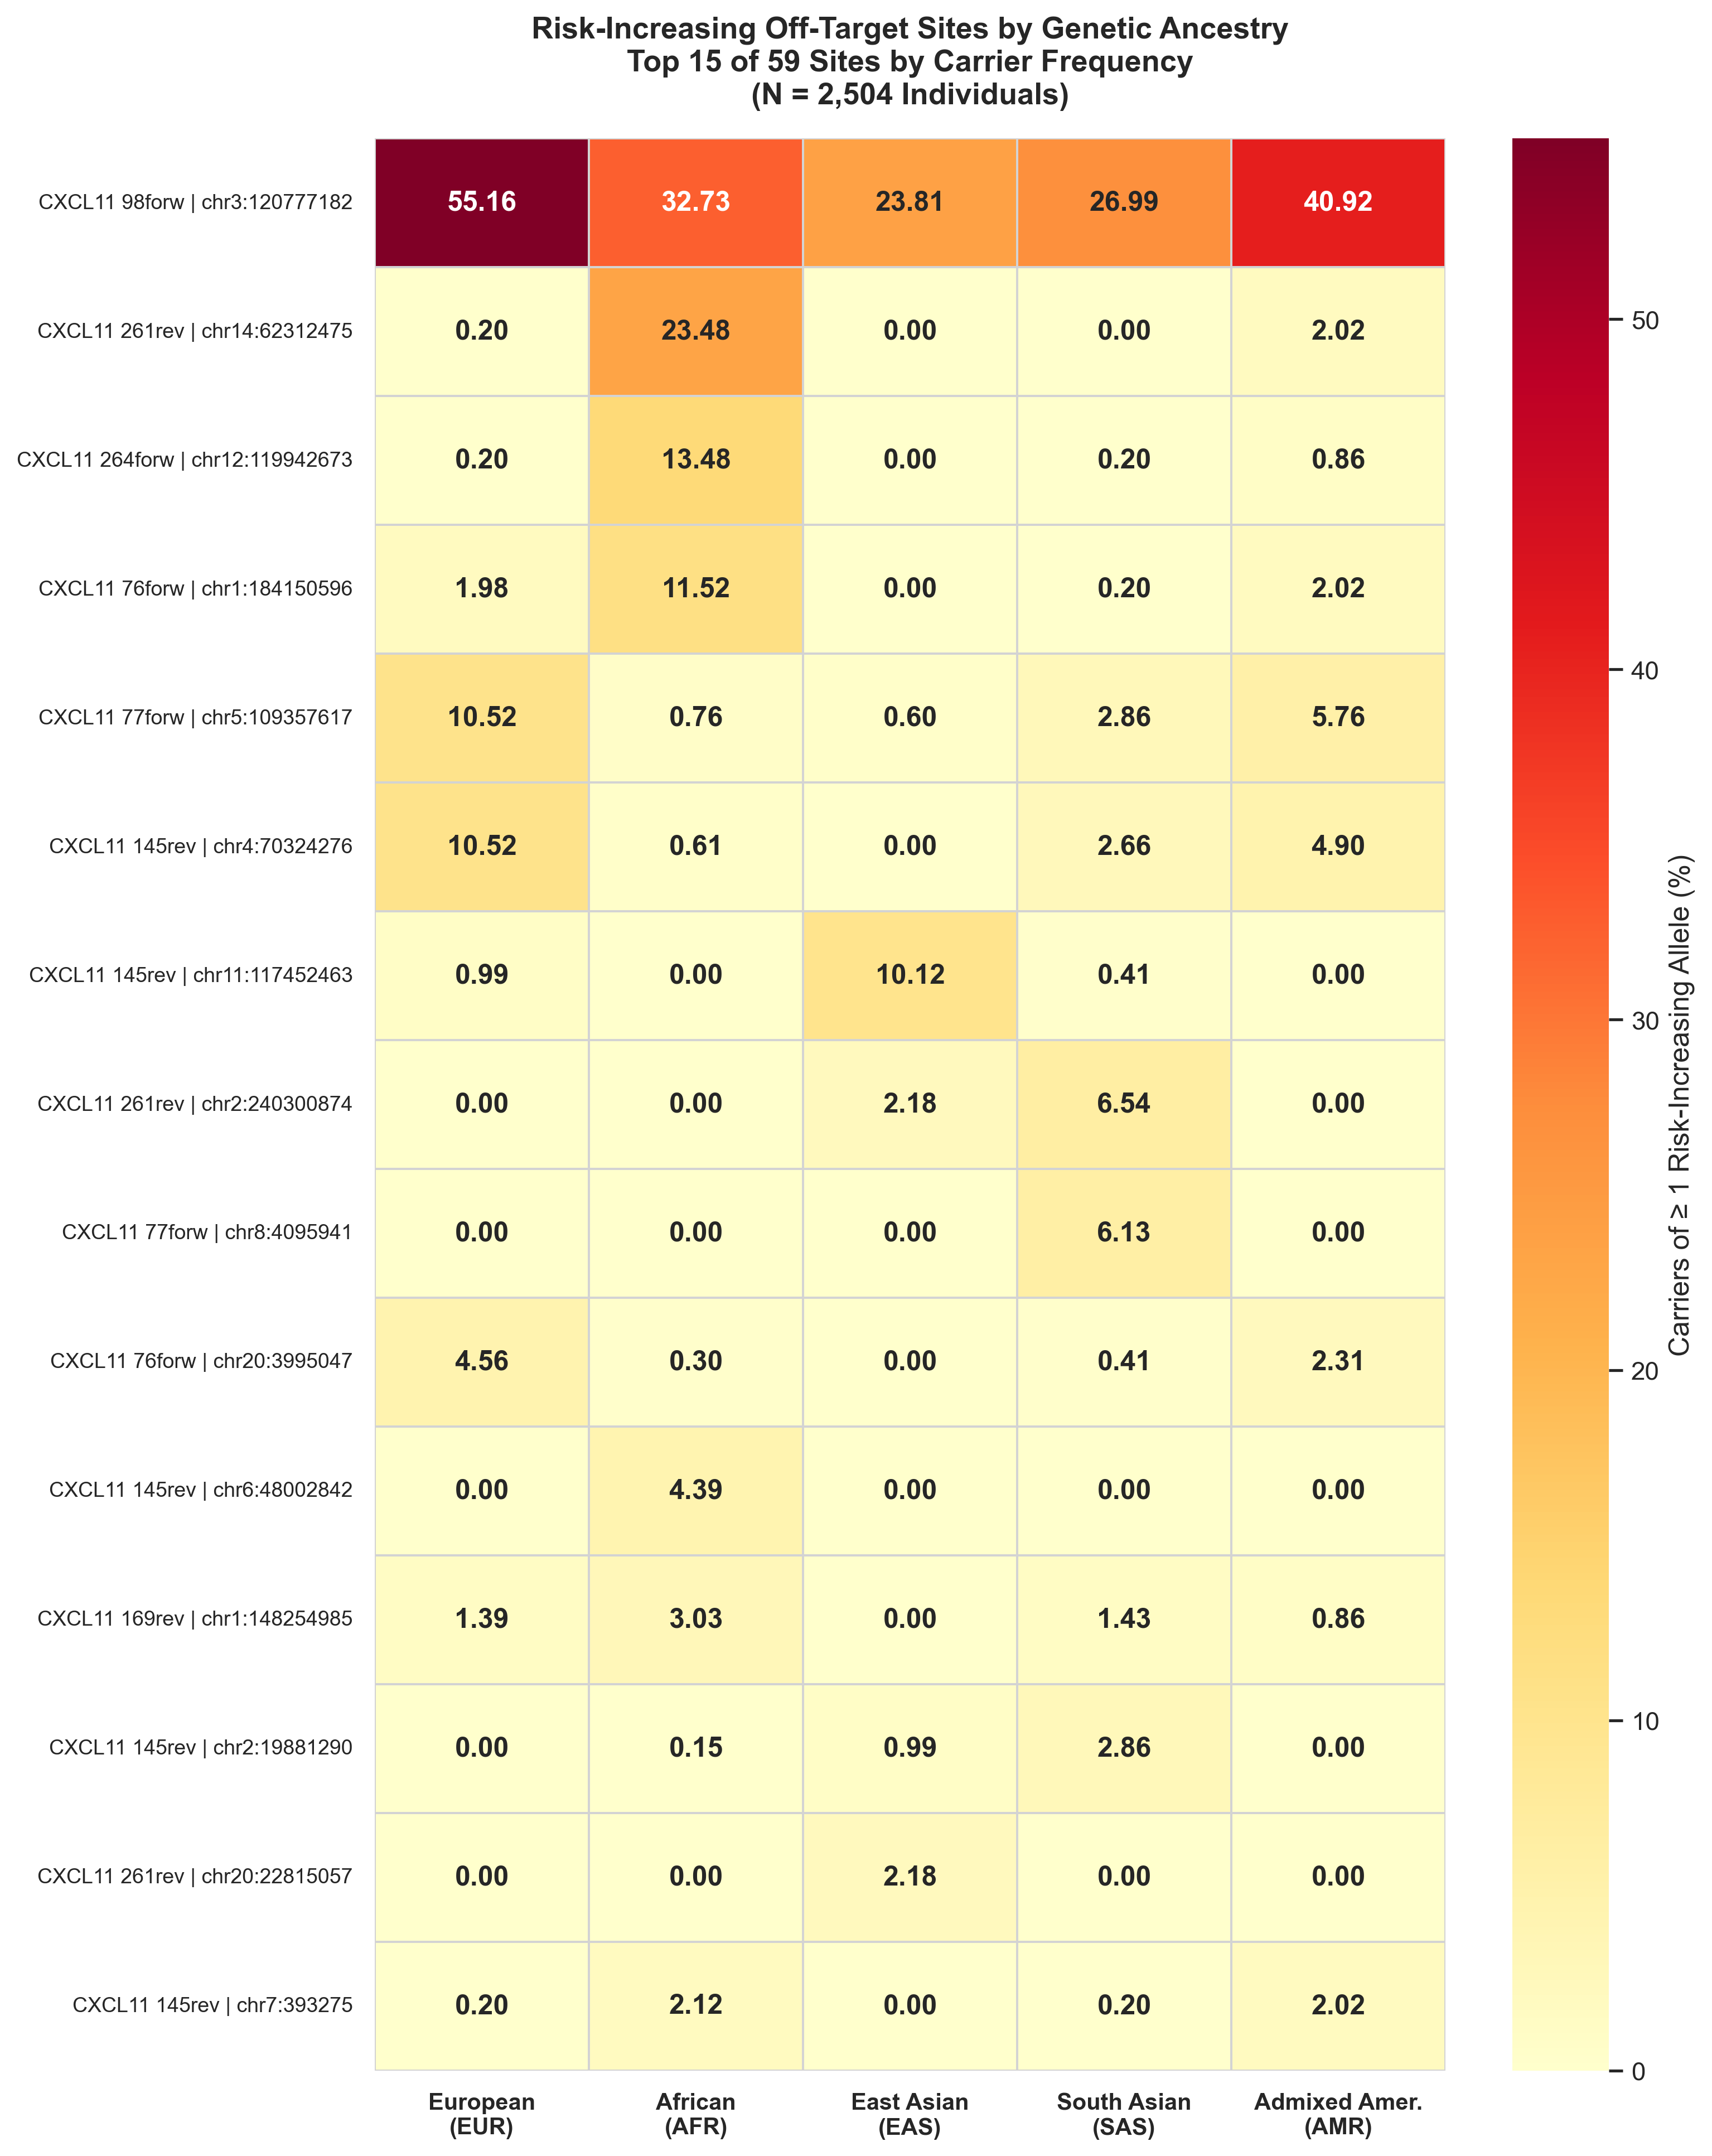

In [11]:
# Where the off-target events are, now that every autosome is covered.
if len(altered_df) == 0:
    display(Markdown('No altered off-target events.'))
else:
    effects_by_chrom = altered_df.groupby(['chrom', 'offtarget_effect']).size().unstack(fill_value=0)
    effects_by_chrom = effects_by_chrom.loc[sorted(effects_by_chrom.index, key=chrom_order)]
    effects_by_chrom.to_csv(TABLE_DIR / 'task3_n2504_genome_wide_offtarget_effects_by_chromosome.tsv', sep='\t')
    display(Markdown('**Off-target events by chromosome (haplotype observations)**'))
    display(effects_by_chrom)

    risk_up = altered_df[altered_df['offtarget_effect'].isin(['CREATED', 'INCREASED'])]
    display(Markdown(f'**Risk-increasing observations: `{len(risk_up):,}`**'))
    if len(risk_up):
        by_guide = risk_up.groupby(['gene', 'guide_id']).agg(
            observations=('offtarget_id', 'size'),
            sites=('offtarget_id', 'nunique'),
            individuals=('sample_id', 'nunique'),
            chromosomes=('chrom', lambda s: ', '.join(sorted(set(s), key=chrom_order))),
        )
        display(by_guide)
        by_guide.to_csv(TABLE_DIR / 'task3_n2504_genome_wide_risk_increasing_by_guide.tsv', sep='\t')

    # With a single gene the split-by-gene path is inert, so the gene is named
    # in the title and the file name explicitly.
    plot_offtarget_events_by_chromosome(
        altered_df,
        output_path=FIGURE_DIR / 'task3_n2504_genome_wide_offtarget_events_by_chromosome_cxcl11.png',
        title='CXCL11: Count of Predicted Off-Target Risk Events by Chromosome',
    )

    plot_offtarget_events_by_guide(
        altered_df,
        all_guides=guides,
        output_path=FIGURE_DIR / 'task3_n2504_genome_wide_offtarget_events_by_guide_cxcl11.png',
        title='CXCL11: Off-target Risk Count by Guide',
    )

    # Where each guide's risk-increasing sites actually are, with carrier
    # counts and a per-super-population breakdown.
    site_report = risk_increasing_site_report(
        altered_df, validated_offtargets, cohort_size=len(SAMPLES), metadata=sample_metadata)
    site_report.to_csv(TABLE_DIR / 'task3_n2504_genome_wide_risk_increasing_sites.tsv',
                       sep='\t', index=False)
    display(Markdown(f'**Risk-increasing candidate sites: `{len(site_report)}`**'))
    display(site_report.head(20))

    guide_by_chrom = risk_increasing_guide_by_chromosome(altered_df)
    guide_by_chrom.to_csv(
        TABLE_DIR / 'task3_n2504_genome_wide_risk_increasing_by_guide_chromosome.tsv', sep='\t')
    display(Markdown('**Risk-increasing observations per guide, by chromosome**'))
    display(guide_by_chrom)

    # Carrier percentage per super-population at each risk-increasing site.
    population_sizes = sample_metadata['super_population'].value_counts().to_dict()
    ancestry_pct, ancestry_n = plot_risk_site_ancestry_heatmap(
        altered_df,
        population_sizes=population_sizes,
        output_path=FIGURE_DIR / 'task3_n2504_genome_wide_risk_site_ancestry.png',
    )
    if ancestry_pct is not None:
        ancestry_pct.round(3).to_csv(TABLE_DIR / 'task3_n2504_genome_wide_risk_site_ancestry_pct.tsv', sep='\t')
        ancestry_n.to_csv(TABLE_DIR / 'task3_n2504_genome_wide_risk_site_ancestry_carriers.tsv', sep='\t')